# Cashflow Forecasting 13 Minggu - Final Notebook

Notebook ini membuat forecasting cashflow 13 minggu ke depan menggunakan pendekatan:

**External Dataset Training + Internal Data Inference + Internal Trend Calibration + Scenario Analysis**

Data internal hanya tersedia 8 minggu sehingga belum cukup untuk melatih model forecasting yang stabil. Oleh karena itu, beberapa dataset external digunakan sebagai training data agar model dapat mempelajari pola umum cashflow.

Namun, data external belum tentu memiliki karakteristik yang sama dengan data aktual. Karena itu, hasil direct model tidak dijadikan output utama. Direct model hanya digunakan sebagai intermediate forecast, lalu hasilnya dikalibrasi menggunakan tren netflow internal 4 minggu terakhir. Output utama notebook adalah forecast 13 minggu dalam 3 skenario: **Base Case Calibrated**, **Optimistic Scenario**, dan **Pessimistic Scenario**.

## 1. Import Library

Notebook menggunakan `pandas`, `numpy`, `matplotlib`, `sklearn`, `pathlib`, dan `warnings`.

Model utama adalah `RandomForestRegressor`. Jika tersedia, notebook juga mencoba `XGBoostRegressor` dan `LightGBMRegressor`. Jika XGBoost atau LightGBM belum terinstall, notebook otomatis fallback ke Random Forest.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print("XGBoost tersedia.")
except ImportError:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    print("XGBoost tidak tersedia. Akan fallback ke model lain.")

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
    print("LightGBM tersedia.")
except ImportError:
    LGBMRegressor = None
    LIGHTGBM_AVAILABLE = False
    print("LightGBM tidak tersedia. Akan fallback ke model lain.")

XGBoost tidak tersedia. Akan fallback ke model lain.
LightGBM tidak tersedia. Akan fallback ke model lain.


## 2. Load Data

Data yang digunakan:

- Data internal: `cashflow_weekly_summary.csv`
- Data external


In [2]:
PROJECT_DIR = Path.cwd()

INTERNAL_DATA_PATH = "cashflow_weekly_summary.csv"
EXTERNAL_DATA_FOLDER = "data_external"
OUTPUT_FOLDER = "outputs"

INTERNAL_FALLBACK_PATHS = [
    "dataset/cashflow_weekly_summary.csv",
    "cashflow_weekly_summary.csv",
]
EXTERNAL_FALLBACK_FOLDERS = [
    "dataset",
    ".",
]


def resolve_file_path(path_value, fallback_paths=None):
    path = Path(path_value)
    if not path.is_absolute():
        path = PROJECT_DIR / path
    if path.exists():
        return path

    for fallback in fallback_paths or []:
        fallback_path = Path(fallback)
        if not fallback_path.is_absolute():
            fallback_path = PROJECT_DIR / fallback_path
        if fallback_path.exists():
            print(f"File tidak ditemukan di {path}. Menggunakan fallback: {fallback_path}")
            return fallback_path

    raise FileNotFoundError(f"File tidak ditemukan: {path}")


def resolve_folder_path(folder_value, fallback_folders=None):
    folder = Path(folder_value)
    if not folder.is_absolute():
        folder = PROJECT_DIR / folder
    if folder.exists():
        return folder

    for fallback in fallback_folders or []:
        fallback_folder = Path(fallback)
        if not fallback_folder.is_absolute():
            fallback_folder = PROJECT_DIR / fallback_folder
        if fallback_folder.exists():
            print(f"Folder tidak ditemukan di {folder}. Menggunakan fallback: {fallback_folder}")
            return fallback_folder

    raise FileNotFoundError(f"Folder external tidak ditemukan: {folder}")


internal_path = resolve_file_path(INTERNAL_DATA_PATH, INTERNAL_FALLBACK_PATHS)
external_folder = resolve_folder_path(EXTERNAL_DATA_FOLDER, EXTERNAL_FALLBACK_FOLDERS)
output_dir = PROJECT_DIR / OUTPUT_FOLDER
output_dir.mkdir(parents=True, exist_ok=True)

internal_raw = pd.read_csv(internal_path)

external_csv_paths = sorted(
    [
        path
        for path in external_folder.rglob("*.csv")
        if path.resolve() != internal_path.resolve()
        and path.name.lower() != "cashflow_weekly_summary.csv"
    ]
)

if not external_csv_paths:
    raise FileNotFoundError(f"Tidak ada file CSV external di folder: {external_folder}")

external_raw_datasets = {}
external_read_errors = []
for path in external_csv_paths:
    try:
        external_raw_datasets[path.name] = {
            "path": path,
            "data": pd.read_csv(path),
        }
    except Exception as exc:
        external_read_errors.append({"file": str(path), "error": str(exc)})

print("Internal data path:", internal_path)
print("External data folder:", external_folder)
print("Jumlah file external terbaca:", len(external_raw_datasets))
print("Output folder:", output_dir)

if external_read_errors:
    print("Beberapa external CSV gagal dibaca:")
    display(pd.DataFrame(external_read_errors))

File tidak ditemukan di C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\cashflow_weekly_summary.csv. Menggunakan fallback: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\dataset\cashflow_weekly_summary.csv
Folder tidak ditemukan di C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\data_external. Menggunakan fallback: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\dataset
Internal data path: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\dataset\cashflow_weekly_summary.csv
External data folder: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\dataset
Jumlah file external terbaca: 4
Output folder: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs


## 3. Data Understanding

Data internal hanya 8 minggu sehingga digunakan data external untuk training model. Namun, data internal tetap digunakan sebagai input terakhir karena merepresentasikan kondisi aktual perusahaan.

Bagian ini menampilkan preview data, jumlah baris dan kolom, missing values, dan statistik deskriptif secara ringkas.

In [3]:
print("Preview data internal:")
display(internal_raw.head())

external_overview_rows = []
for dataset_name, item in external_raw_datasets.items():
    df = item["data"]
    external_overview_rows.append(
        {
            "dataset": dataset_name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "path": str(item["path"]),
        }
    )

external_overview = pd.DataFrame(external_overview_rows)
print("Ringkasan file external:")
display(external_overview)

print("Preview beberapa data external:")
for dataset_name, item in list(external_raw_datasets.items())[:5]:
    print(f"Dataset: {dataset_name}")
    display(item["data"].head())

Preview data internal:


,period,month,week,beginning_balance_rp_juta,total_inflow_rp_juta,total_outflow_rp_juta,netflow_rp_juta,ending_balance_rp_juta
0,May-26 W1,May-26,W1,337737,799295,-1107832,-308537,29200
1,May-26 W2,May-26,W2,29200,173661,-176125,-2464,26736
2,May-26 W3,May-26,W3,26736,376621,-399712,-23090,3646
3,May-26 W4,May-26,W4,3646,708743,-733219,-24476,-20830
4,Jun-26 W1,Jun-26,W1,-20830,566258,-549650,16607,-4223


Ringkasan file external:


,dataset,rows,columns,path
0,accounting_data.csv,1000,18,C:\Users\Ram Wijaya\Documents\ram wijaya\KP ME...
1,cash_in_cash_out.csv,1186,3,C:\Users\Ram Wijaya\Documents\ram wijaya\KP ME...
2,Expenses_clean.csv,938,6,C:\Users\Ram Wijaya\Documents\ram wijaya\KP ME...
3,Income_clean.csv,349,6,C:\Users\Ram Wijaya\Documents\ram wijaya\KP ME...


Preview beberapa data external:
Dataset: accounting_data.csv


...

,Date,CashIn,CashOut
0,01/01/2016,NaN,"6,500.00"
1,01/02/2016,NaN,"23,110.00"
2,01/03/2016,NaN,"7,070.00"
3,01/04/2016,NaN,"18,520.00"
4,01/05/2016,"20,840.00","22,200.00"


Dataset: Expenses_clean.csv


,date_time,category,account,amount,currency,tags
0,2025-11-30 00:00:00,Health,acct_1,114.00,BYN,tag_1
1,2025-11-29 00:00:00,Food,acct_1,5.00,BYN,tag_1
2,2025-11-27 00:00:00,Public transport,acct_2,1.00,BYN,tag_1
3,2025-11-27 00:00:00,Cafe,acct_1,10.00,BYN,tag_1
4,2025-11-27 00:00:00,Public transport,acct_2,1.00,BYN,tag_1


Dataset: Income_clean.csv


,date_time,category,account,amount,currency,tags
0,2025-11-29 00:00:00,Job,acct_1,49.00,BYN,tag_1
1,2025-11-29 00:00:00,Job,acct_1,18.00,BYN,tag_2
2,2025-11-29 00:00:00,Job,acct_1,32.00,BYN,tag_3
3,2025-11-29 00:00:00,Job,acct_1,109.00,BYN,tag_4
4,2025-11-28 00:00:00,Second work,acct_1,132.00,BYN,2th_work


In [4]:
print("Missing values data internal:")
display(internal_raw.isna().sum().to_frame("missing_values"))

external_missing_summary = []
for dataset_name, item in external_raw_datasets.items():
    df = item["data"]
    external_missing_summary.append(
        {
            "dataset": dataset_name,
            "total_missing_values": int(df.isna().sum().sum()),
            "missing_columns": int((df.isna().sum() > 0).sum()),
        }
    )

print("Ringkasan missing values data external:")
display(pd.DataFrame(external_missing_summary))

Missing values data internal:


,missing_values
period,0
month,0
week,0
beginning_balance_rp_juta,0
total_inflow_rp_juta,0
total_outflow_rp_juta,0
netflow_rp_juta,0
ending_balance_rp_juta,0


Ringkasan missing values data external:


,dataset,total_missing_values,missing_columns
0,accounting_data.csv,0,0
1,cash_in_cash_out.csv,193,2
2,Expenses_clean.csv,0,0
3,Income_clean.csv,0,0


In [5]:
print("Statistik deskriptif data internal:")
display(internal_raw.describe(include="all"))

print("Statistik deskriptif external secara ringkas:")
for dataset_name, item in list(external_raw_datasets.items())[:5]:
    print(f"Dataset: {dataset_name}")
    display(item["data"].describe(include="all").head(12))

Statistik deskriptif data internal:


,period,month,week,beginning_balance_rp_juta,total_inflow_rp_juta,total_outflow_rp_juta,netflow_rp_juta,ending_balance_rp_juta
count,8,8,8,8.00,8.00,8.00,8.00,8.00
unique,8,2,4,NaN,NaN,NaN,NaN,NaN
top,May-26 W1,May-26,W1,NaN,NaN,NaN,NaN,NaN
freq,1,4,2,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,"34,582.50","539,356.38","-594,275.50","-54,919.12","-20,336.62"
std,NaN,NaN,NaN,"126,912.08","227,001.02","288,849.34","104,624.79","46,698.46"
min,NaN,NaN,NaN,"-76,485.00","173,661.00","-1,107,832.00","-308,537.00","-101,616.00"
25%,NaN,NaN,NaN,"-19,548.25","385,837.75","-758,174.25","-33,189.25","-34,743.75"
50%,NaN,NaN,NaN,-288.50,"524,739.50","-529,001.00","-23,783.00","-11,672.00"
75%,NaN,NaN,NaN,"27,352.00","731,381.00","-434,633.50","-11,789.50","9,418.50"


Statistik deskriptif external secara ringkas:
Dataset: accounting_data.csv


,Transaction ID,Date,Account Type,Transaction Amount,Cash Flow,Net Income,Revenue,Expenditure,Profit Margin,Debt-to-Equity Ratio,Operating Expenses,Gross Profit,Transaction Volume,Processing Time (seconds),Accuracy Score,Missing Data Indicator,Normalized Transaction Amount,Transaction Outcome
count,"1,000.00",1000,1000,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00",1000,"1,000.00","1,000.00"
unique,NaN,1000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,2025-01-01,Expense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
freq,NaN,1,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,952,NaN,NaN
mean,500.50,NaN,NaN,"2,535.70","2,426.33","2,114.76","2,610.99","2,026.19",0.50,1.78,"2,517.95","2,039.06",4.99,1.24,0.90,NaN,0.50,0.95
std,288.82,NaN,NaN,"1,432.05","1,169.85","1,100.61","1,358.79","1,129.05",0.17,0.72,"1,418.45","1,128.13",2.59,0.44,0.06,NaN,0.29,0.22
min,1.00,NaN,NaN,106.00,502.00,203.00,303.00,100.00,0.20,0.50,103.00,101.00,1.00,0.50,0.80,NaN,0.00,0.00
25%,250.75,NaN,NaN,"1,363.50","1,360.75","1,168.75","1,426.00","1,004.75",0.35,1.16,"1,290.00","1,067.00",3.00,0.86,0.85,NaN,0.26,1.00
50%,500.50,NaN,NaN,"2,498.00","2,452.00","2,075.50","2,570.50","2,048.00",0.49,1.82,"2,549.00","2,039.00",5.00,1.21,0.90,NaN,0.49,1.00
75%,750.25,NaN,NaN,"3,774.00","3,414.00","3,078.50","3,776.50","3,009.50",0.64,2.38,"3,735.50","3,007.50",7.00,1.62,0.95,NaN,0.75,1.00


Dataset: cash_in_cash_out.csv


,Date,CashIn,CashOut
count,1186,"1,081.00","1,098.00"
unique,1186,NaN,NaN
top,01/01/2016,NaN,NaN
freq,1,NaN,NaN
mean,NaN,"37,261.62","30,923.04"
std,NaN,"20,583.19","18,315.12"
min,NaN,100.00,0.00
25%,NaN,"21,690.00","17,947.50"
50%,NaN,"34,980.00","27,810.00"
75%,NaN,"50,280.00","40,350.00"


Dataset: Expenses_clean.csv


,date_time,category,account,amount,currency,tags
count,938,938,938,938.00,938,938
unique,280,14,3,NaN,1,7
top,2025-10-29 00:00:00,Public transport,acct_2,NaN,BYN,tag_1
freq,9,414,400,NaN,938,660
mean,NaN,NaN,NaN,15.84,NaN,NaN
std,NaN,NaN,NaN,78.29,NaN,NaN
min,NaN,NaN,NaN,0.00,NaN,NaN
25%,NaN,NaN,NaN,1.00,NaN,NaN
50%,NaN,NaN,NaN,2.00,NaN,NaN
75%,NaN,NaN,NaN,10.00,NaN,NaN


Dataset: Income_clean.csv


,date_time,category,account,amount,currency,tags
count,349,349,349,349.00,349,349
unique,209,7,5,NaN,1,9
top,2025-09-27 00:00:00,Job,acct_1,NaN,BYN,tag_5
freq,6,216,312,NaN,349,167
mean,NaN,NaN,NaN,76.30,NaN,NaN
std,NaN,NaN,NaN,150.10,NaN,NaN
min,NaN,NaN,NaN,2.00,NaN,NaN
25%,NaN,NaN,NaN,20.00,NaN,NaN
50%,NaN,NaN,NaN,36.00,NaN,NaN
75%,NaN,NaN,NaN,67.00,NaN,NaN


## 4. Standardisasi Data External

Setiap data external diubah menjadi format weekly cashflow:

- `period`
- `total_inflow`
- `total_outflow`
- `netflow`
- `beginning_balance`
- `ending_balance`
- `week_number`

Fungsi `standardize_external_cashflow(df, config)` mendukung dua bentuk data:

1. Data sudah memiliki kolom cash in dan cash out.
2. Data berbentuk transaksi dengan kolom tanggal, type/category, dan amount.

Jika data external berbeda mata uang atau skala, nilainya tidak dianggap sama dengan Rupiah. Model menggunakan scaling dan target ratio agar lebih fokus pada pola, bukan nominal mentah.

In [6]:
def clean_column_name(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def clean_columns(df):
    result = df.copy()
    result.columns = [clean_column_name(col) for col in result.columns]
    return result


def find_column(df, candidates, required=False, label=None):
    cleaned_candidates = [clean_column_name(candidate) for candidate in candidates if candidate]
    for candidate in cleaned_candidates:
        if candidate in df.columns:
            return candidate

    if required:
        label = label or "/".join(cleaned_candidates)
        raise KeyError(f"Kolom untuk {label} tidak ditemukan. Kolom tersedia: {list(df.columns)}")
    return None


def parse_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)

    cleaned = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("Rp", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_dates_safely(series, dayfirst=False):
    parsed = pd.to_datetime(series, errors="coerce", dayfirst=dayfirst)
    if parsed.isna().mean() > 0.5:
        parsed_alt = pd.to_datetime(series, errors="coerce", dayfirst=not dayfirst)
        if parsed_alt.isna().sum() < parsed.isna().sum():
            parsed = parsed_alt
    return parsed


def label_contains(value, labels):
    value = str(value).strip().lower().replace("_", " ").replace("-", " ")
    return any(str(label).lower().replace("_", " ").replace("-", " ") in value for label in labels)


def simulate_balances(weekly_df):
    result = weekly_df.copy()
    result["beginning_balance"] = result["netflow"].cumsum().shift(1, fill_value=0)
    result["ending_balance"] = result["beginning_balance"] + result["netflow"]
    return result


DEFAULT_EXTERNAL_CONFIG = {
    "date_col": "date",
    "type_col": "type",
    "amount_col": "amount",
    "cash_in_col": None,
    "cash_out_col": None,
    "beginning_balance_col": None,
    "ending_balance_col": None,
    "inflow_labels": ["cash in", "cash-in", "income", "revenue", "credit", "deposit", "job", "salary"],
    "outflow_labels": ["cash out", "cash-out", "expense", "payment", "debit", "withdrawal", "health", "food", "transport"],
    "dayfirst": False,
    "forced_flow_type": None,
}


def infer_external_config(path, df):
    data = clean_columns(df)
    config = DEFAULT_EXTERNAL_CONFIG.copy()
    file_text = str(path).lower()

    date_col = find_column(data, ["date", "date_time", "transaction_date", "posting_date"], required=False)
    type_col = find_column(data, ["type", "category", "account_type", "transaction_type", "cashflow_type"], required=False)
    amount_col = find_column(data, ["amount", "transaction_amount", "value", "nominal"], required=False)
    cash_in_col = find_column(data, ["cashin", "cash_in", "cash_inflow", "inflow", "income"], required=False)
    cash_out_col = find_column(data, ["cashout", "cash_out", "cash_outflow", "outflow", "expense"], required=False)

    if "cash_in_cash_out" in file_text:
        cash_in_col = find_column(data, ["cashin", "cash_in", "cash_inflow"], required=False)
        cash_out_col = find_column(data, ["cashout", "cash_out", "cash_outflow"], required=False)

    if "accounting_data" in file_text:
        date_col = find_column(data, ["date"], required=False)
        cash_in_col = find_column(data, ["revenue"], required=False)
        cash_out_col = find_column(data, ["expenditure", "operating_expenses"], required=False)
        type_col = find_column(data, ["account_type"], required=False)
        amount_col = find_column(data, ["transaction_amount"], required=False)

    if "income" in file_text and amount_col:
        config["forced_flow_type"] = "inflow"
    if "expense" in file_text and amount_col:
        config["forced_flow_type"] = "outflow"

    config.update(
        {
            "date_col": date_col,
            "type_col": type_col,
            "amount_col": amount_col,
            "cash_in_col": cash_in_col,
            "cash_out_col": cash_out_col,
        }
    )
    return config


def standardize_external_cashflow(df, config):
    data = clean_columns(df)
    config = {**DEFAULT_EXTERNAL_CONFIG, **(config or {})}

    date_col = find_column(data, [config.get("date_col"), "date", "date_time", "transaction_date", "posting_date"], required=False)
    type_col = find_column(data, [config.get("type_col"), "type", "category", "account_type", "transaction_type"], required=False)
    amount_col = find_column(data, [config.get("amount_col"), "amount", "transaction_amount", "value", "nominal"], required=False)
    cash_in_col = find_column(data, [config.get("cash_in_col"), "cashin", "cash_in", "inflow", "income", "revenue"], required=False)
    cash_out_col = find_column(data, [config.get("cash_out_col"), "cashout", "cash_out", "outflow", "expense", "expenditure"], required=False)
    beginning_col = find_column(data, [config.get("beginning_balance_col"), "beginning_balance", "opening_balance"], required=False)
    ending_col = find_column(data, [config.get("ending_balance_col"), "ending_balance", "closing_balance"], required=False)

    working = pd.DataFrame(index=data.index)
    working["date"] = parse_dates_safely(data[date_col], dayfirst=config.get("dayfirst", False)) if date_col else pd.NaT

    if cash_in_col and cash_out_col:
        working["total_inflow"] = parse_numeric(data[cash_in_col]).fillna(0).abs()
        working["total_outflow"] = -parse_numeric(data[cash_out_col]).fillna(0).abs()
        source_format = "cash_in_cash_out"
    elif amount_col:
        amount = parse_numeric(data[amount_col]).fillna(0).abs()
        forced_flow_type = config.get("forced_flow_type")

        if forced_flow_type == "inflow":
            inflow_mask = pd.Series(True, index=data.index)
            outflow_mask = pd.Series(False, index=data.index)
        elif forced_flow_type == "outflow":
            inflow_mask = pd.Series(False, index=data.index)
            outflow_mask = pd.Series(True, index=data.index)
        elif type_col:
            type_values = data[type_col].astype(str)
            inflow_mask = type_values.apply(lambda value: label_contains(value, config["inflow_labels"]))
            outflow_mask = type_values.apply(lambda value: label_contains(value, config["outflow_labels"]))
        else:
            raise ValueError("Data transaksi membutuhkan type/category atau forced_flow_type.")

        working["total_inflow"] = np.where(inflow_mask, amount, 0)
        working["total_outflow"] = np.where(outflow_mask, -amount, 0)
        source_format = "transaction"
    else:
        raise ValueError("Data external tidak memiliki cash in/out atau amount yang dapat dipakai.")

    working["netflow"] = working["total_inflow"] + working["total_outflow"]

    if beginning_col:
        working["beginning_balance_raw"] = parse_numeric(data[beginning_col])
    if ending_col:
        working["ending_balance_raw"] = parse_numeric(data[ending_col])

    if working["date"].notna().any():
        working = working.dropna(subset=["date"]).sort_values("date")
        working["week_start"] = working["date"].dt.to_period("W-SUN").apply(lambda period: period.start_time)

        agg_dict = {"total_inflow": "sum", "total_outflow": "sum", "netflow": "sum"}
        if "beginning_balance_raw" in working.columns:
            agg_dict["beginning_balance_raw"] = "first"
        if "ending_balance_raw" in working.columns:
            agg_dict["ending_balance_raw"] = "last"

        weekly = working.groupby("week_start", as_index=False).agg(agg_dict)
        weekly["period"] = weekly["week_start"].dt.strftime("%Y-%m-%d")
        weekly["week_number"] = weekly["week_start"].dt.isocalendar().week.astype(int)
    else:
        weekly = working.reset_index(drop=True).copy()
        weekly["period"] = [f"External Week {idx}" for idx in range(1, len(weekly) + 1)]
        weekly["week_number"] = np.arange(1, len(weekly) + 1)

    if {"beginning_balance_raw", "ending_balance_raw"}.issubset(weekly.columns):
        weekly["beginning_balance"] = weekly["beginning_balance_raw"]
        weekly["ending_balance"] = weekly["ending_balance_raw"]
    else:
        weekly = simulate_balances(weekly)

    weekly["total_inflow"] = weekly["total_inflow"].abs()
    weekly["total_outflow"] = -weekly["total_outflow"].abs()
    weekly["netflow"] = weekly["total_inflow"] + weekly["total_outflow"]
    weekly["ending_balance"] = weekly["beginning_balance"] + weekly["netflow"]
    weekly["source_format"] = source_format

    return weekly[
        [
            "period",
            "total_inflow",
            "total_outflow",
            "netflow",
            "beginning_balance",
            "ending_balance",
            "week_number",
            "source_format",
        ]
    ].reset_index(drop=True)

In [7]:
standardized_external_frames = []
standardization_log = []

for dataset_name, item in external_raw_datasets.items():
    path = item["path"]
    df = item["data"]
    config = infer_external_config(path, df)
    try:
        standardized = standardize_external_cashflow(df, config)
        standardized["source_dataset"] = dataset_name
        standardized_external_frames.append(standardized)
        standardization_log.append(
            {
                "dataset": dataset_name,
                "status": "success",
                "weekly_rows": len(standardized),
                "source_format": standardized["source_format"].iloc[0] if len(standardized) else None,
                "config": str({key: config.get(key) for key in ["date_col", "type_col", "amount_col", "cash_in_col", "cash_out_col", "forced_flow_type"]}),
            }
        )
    except Exception as exc:
        standardization_log.append(
            {
                "dataset": dataset_name,
                "status": "failed",
                "weekly_rows": 0,
                "source_format": None,
                "config": str({key: config.get(key) for key in ["date_col", "type_col", "amount_col", "cash_in_col", "cash_out_col", "forced_flow_type"]}),
                "error": str(exc),
            }
        )

standardization_summary = pd.DataFrame(standardization_log)
display(standardization_summary)

if not standardized_external_frames:
    raise ValueError("Tidak ada dataset external yang berhasil distandardisasi.")

external_weekly_all = pd.concat(standardized_external_frames, ignore_index=True)
print("Total baris weekly external:", len(external_weekly_all))
display(external_weekly_all.head())

,dataset,status,weekly_rows,source_format,config
0,accounting_data.csv,success,144,cash_in_cash_out,"{'date_col': 'date', 'type_col': 'account_type..."
1,cash_in_cash_out.csv,success,170,cash_in_cash_out,"{'date_col': 'date', 'type_col': None, 'amount..."
2,Expenses_clean.csv,success,47,transaction,"{'date_col': 'date_time', 'type_col': 'categor..."
3,Income_clean.csv,success,48,transaction,"{'date_col': 'date_time', 'type_col': 'categor..."


Total baris weekly external: 409


,period,total_inflow,total_outflow,netflow,beginning_balance,ending_balance,week_number,source_format,source_dataset
0,2024-12-30,"20,523.00","-9,123.00","11,400.00",0.00,"11,400.00",1,cash_in_cash_out,accounting_data.csv
1,2025-01-06,"15,023.00","-16,084.00","-1,061.00","11,400.00","10,339.00",2,cash_in_cash_out,accounting_data.csv
2,2025-01-13,"19,856.00","-15,767.00","4,089.00","10,339.00","14,428.00",3,cash_in_cash_out,accounting_data.csv
3,2025-01-20,"14,278.00","-10,522.00","3,756.00","14,428.00","18,184.00",4,cash_in_cash_out,accounting_data.csv
4,2025-01-27,"22,661.00","-12,076.00","10,585.00","18,184.00","28,769.00",5,cash_in_cash_out,accounting_data.csv


## 5. Preprocessing Data Internal

Data internal dibersihkan agar numeric, outflow negatif, netflow dan ending balance konsisten, serta week number berurutan.

Jika ada selisih kecil karena rounding Excel, validasi menggunakan toleransi.

In [8]:
def preprocess_internal_data(df):
    data = clean_columns(df)

    period_col = find_column(data, ["period"], required=False)
    month_col = find_column(data, ["month"], required=False)
    week_col = find_column(data, ["week"], required=False)
    beginning_col = find_column(data, ["beginning_balance", "beginning_balance_rp_juta", "opening_balance"], required=True, label="beginning_balance")
    inflow_col = find_column(data, ["total_inflow", "total_inflow_rp_juta", "cash_in", "cashin", "inflow"], required=True, label="total_inflow")
    outflow_col = find_column(data, ["total_outflow", "total_outflow_rp_juta", "cash_out", "cashout", "outflow"], required=True, label="total_outflow")
    week_number_col = find_column(data, ["week_number"], required=False)

    if period_col:
        period = data[period_col].astype(str)
    elif month_col and week_col:
        period = data[month_col].astype(str) + " " + data[week_col].astype(str)
    else:
        period = pd.Series([f"Week {idx}" for idx in range(1, len(data) + 1)], index=data.index)

    if week_number_col:
        week_number = parse_numeric(data[week_number_col]).astype(int)
    else:
        week_number = np.arange(1, len(data) + 1)

    result = pd.DataFrame(
        {
            "period": period,
            "total_inflow": parse_numeric(data[inflow_col]).abs(),
            "total_outflow": -parse_numeric(data[outflow_col]).abs(),
            "beginning_balance": parse_numeric(data[beginning_col]),
            "week_number": week_number,
        }
    )
    result["netflow"] = result["total_inflow"] + result["total_outflow"]
    result["ending_balance"] = result["beginning_balance"] + result["netflow"]
    result["week_number"] = np.arange(1, len(result) + 1)

    result = result[
        [
            "period",
            "total_inflow",
            "total_outflow",
            "netflow",
            "beginning_balance",
            "ending_balance",
            "week_number",
        ]
    ].reset_index(drop=True)

    result["netflow_check"] = result["total_inflow"] + result["total_outflow"]
    result["ending_balance_check"] = result["beginning_balance"] + result["netflow"]
    result["netflow_diff"] = result["netflow"] - result["netflow_check"]
    result["ending_balance_diff"] = result["ending_balance"] - result["ending_balance_check"]

    tolerance = 1e-6
    if (result[["netflow_diff", "ending_balance_diff"]].abs() > tolerance).any().any():
        print("Ada selisih validasi di atas toleransi. Nilai sudah dihitung ulang agar konsisten.")

    return result.drop(columns=["netflow_check", "ending_balance_check", "netflow_diff", "ending_balance_diff"])


internal_weekly = preprocess_internal_data(internal_raw)
print("Data internal setelah preprocessing:")
display(internal_weekly)

Data internal setelah preprocessing:


,period,total_inflow,total_outflow,netflow,beginning_balance,ending_balance,week_number
0,May-26 W1,"799,295.00","-1,107,832.00","-308,537.00","337,737.00","29,200.00",1
1,May-26 W2,"173,661.00","-176,125.00","-2,464.00","29,200.00","26,736.00",2
2,May-26 W3,"376,621.00","-399,712.00","-23,091.00","26,736.00","3,645.00",3
3,May-26 W4,"708,743.00","-733,219.00","-24,476.00","3,646.00","-20,830.00",4
4,Jun-26 W1,"566,258.00","-549,650.00","16,608.00","-20,830.00","-4,222.00",5
5,Jun-26 W2,"818,142.00","-833,040.00","-14,898.00","-4,223.00","-19,121.00",6
6,Jun-26 W3,"388,910.00","-446,274.00","-57,364.00","-19,121.00","-76,485.00",7
7,Jun-26 W4,"483,221.00","-508,352.00","-25,131.00","-76,485.00","-101,616.00",8


## 6. Feature Engineering

Fungsi `create_time_series_features(df, max_lag=4)` membuat fitur time series:

- `inflow_lag_1` sampai `inflow_lag_4`
- `outflow_lag_1` sampai `outflow_lag_4`
- `netflow_lag_1` sampai `netflow_lag_4`
- `ending_balance_lag_1` sampai `ending_balance_lag_4`
- `inflow_rolling_mean_4`
- `outflow_rolling_mean_4`
- `netflow_rolling_mean_4`
- `ending_balance_rolling_mean_4`
- `week_number`

Target:

- `next_week_inflow`
- `next_week_outflow`

In [9]:
def safe_scale(series, fallback=1.0):
    result = series.replace([np.inf, -np.inf], np.nan).fillna(fallback)
    return result.replace(0, fallback)


def create_time_series_features(df, max_lag=4):
    data = df.copy().reset_index(drop=True)
    group_col = "source_dataset" if "source_dataset" in data.columns else None
    groups = data.groupby(group_col, sort=False) if group_col else [(None, data)]
    feature_frames = []

    for source_name, group in groups:
        group = group.copy().reset_index(drop=True)

        lag_source = {
            "inflow": "total_inflow",
            "outflow": "total_outflow",
            "netflow": "netflow",
            "ending_balance": "ending_balance",
        }

        for feature_name, source_col in lag_source.items():
            for lag in range(1, max_lag + 1):
                group[f"{feature_name}_lag_{lag}"] = group[source_col].shift(lag - 1)

        group["inflow_rolling_mean_4"] = group["total_inflow"].rolling(window=max_lag).mean()
        group["outflow_rolling_mean_4"] = group["total_outflow"].rolling(window=max_lag).mean()
        group["netflow_rolling_mean_4"] = group["netflow"].rolling(window=max_lag).mean()
        group["ending_balance_rolling_mean_4"] = group["ending_balance"].rolling(window=max_lag).mean()

        group["next_week_inflow"] = group["total_inflow"].shift(-1)
        group["next_week_outflow"] = group["total_outflow"].shift(-1)

        group["inflow_scale_reference"] = safe_scale(
            group["inflow_rolling_mean_4"].abs(),
            fallback=max(group["total_inflow"].abs().mean(), 1),
        )
        group["outflow_scale_reference"] = safe_scale(
            group["outflow_rolling_mean_4"].abs(),
            fallback=max(group["total_outflow"].abs().mean(), 1),
        )

        group["next_week_inflow_ratio"] = group["next_week_inflow"] / group["inflow_scale_reference"]
        group["next_week_outflow_ratio"] = group["next_week_outflow"] / group["outflow_scale_reference"]

        feature_frames.append(group)

    feature_data = pd.concat(feature_frames, ignore_index=True)
    feature_data = feature_data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return feature_data


feature_data = create_time_series_features(external_weekly_all, max_lag=4)

FEATURE_COLUMNS = (
    [f"inflow_lag_{lag}" for lag in range(1, 5)]
    + [f"outflow_lag_{lag}" for lag in range(1, 5)]
    + [f"netflow_lag_{lag}" for lag in range(1, 5)]
    + [f"ending_balance_lag_{lag}" for lag in range(1, 5)]
    + [
        "inflow_rolling_mean_4",
        "outflow_rolling_mean_4",
        "netflow_rolling_mean_4",
        "ending_balance_rolling_mean_4",
        "week_number",
    ]
)

print("Jumlah baris feature_data:", len(feature_data))
print("Jumlah fitur:", len(FEATURE_COLUMNS))
display(feature_data[FEATURE_COLUMNS + ["next_week_inflow", "next_week_outflow"]].head())

Jumlah baris feature_data: 393
Jumlah fitur: 21


,inflow_lag_1,inflow_lag_2,inflow_lag_3,inflow_lag_4,outflow_lag_1,outflow_lag_2,outflow_lag_3,outflow_lag_4,netflow_lag_1,netflow_lag_2,netflow_lag_3,netflow_lag_4,ending_balance_lag_1,ending_balance_lag_2,ending_balance_lag_3,ending_balance_lag_4,inflow_rolling_mean_4,outflow_rolling_mean_4,netflow_rolling_mean_4,ending_balance_rolling_mean_4,week_number,next_week_inflow,next_week_outflow
0,"14,278.00","19,856.00","15,023.00","20,523.00","-10,522.00","-15,767.00","-16,084.00","-9,123.00","3,756.00","4,089.00","-1,061.00","11,400.00","18,184.00","14,428.00","10,339.00","11,400.00","17,420.00","-12,874.00","4,546.00","13,587.75",4,"22,661.00","-12,076.00"
1,"22,661.00","14,278.00","19,856.00","15,023.00","-12,076.00","-10,522.00","-15,767.00","-16,084.00","10,585.00","3,756.00","4,089.00","-1,061.00","28,769.00","18,184.00","14,428.00","10,339.00","17,954.50","-13,612.25","4,342.25","17,930.00",5,"21,912.00","-14,122.00"
2,"21,912.00","22,661.00","14,278.00","19,856.00","-14,122.00","-12,076.00","-10,522.00","-15,767.00","7,790.00","10,585.00","3,756.00","4,089.00","36,559.00","28,769.00","18,184.00","14,428.00","19,676.75","-13,121.75","6,555.00","24,485.00",6,"20,778.00","-17,638.00"
3,"20,778.00","21,912.00","22,661.00","14,278.00","-17,638.00","-14,122.00","-12,076.00","-10,522.00","3,140.00","7,790.00","10,585.00","3,756.00","39,699.00","36,559.00","28,769.00","18,184.00","19,907.25","-13,589.50","6,317.75","30,802.75",7,"22,470.00","-19,511.00"
4,"22,470.00","20,778.00","21,912.00","22,661.00","-19,511.00","-17,638.00","-14,122.00","-12,076.00","2,959.00","3,140.00","7,790.00","10,585.00","42,658.00","39,699.00","36,559.00","28,769.00","21,955.25","-15,836.75","6,118.50","36,921.25",8,"16,862.00","-13,312.00"


## 7. Train Validation Test Split

Karena data adalah time series, split dilakukan berdasarkan urutan waktu dan **tidak menggunakan random shuffle**.

Proporsi:

- 70% train
- 15% validation
- 15% test

MAE, RMSE, MAPE, dan R2 digunakan untuk evaluasi. MAE dan RMSE mengukur seberapa jauh hasil prediksi dari nilai aktual. Semakin kecil nilainya, semakin baik performa model. Accuracy tidak digunakan karena forecasting cashflow adalah regression problem, bukan classification problem.

In [10]:
def time_based_split_indices(n_rows, train_size=0.70, val_size=0.15):
    if n_rows < 10:
        raise ValueError("Data terlalu sedikit untuk train/validation/test split.")

    train_end = max(int(n_rows * train_size), 1)
    val_end = max(int(n_rows * (train_size + val_size)), train_end + 1)
    val_end = min(val_end, n_rows - 1)

    train_idx = np.arange(0, train_end)
    val_idx = np.arange(train_end, val_end)
    test_idx = np.arange(val_end, n_rows)
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = time_based_split_indices(len(feature_data))

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_idx), len(val_idx), len(test_idx)],
        "percentage": [len(train_idx) / len(feature_data), len(val_idx) / len(feature_data), len(test_idx) / len(feature_data)],
    }
)
display(split_summary)

,split,rows,percentage
0,train,275,0.70
1,validation,59,0.15
2,test,59,0.15


## 8. Train Multiple Models

Model dilatih untuk dua target:

- `next_week_inflow`
- `next_week_outflow`

Model yang dicoba:

- RandomForestRegressor
- XGBoostRegressor jika tersedia
- LightGBMRegressor jika tersedia

Model terbaik dipilih berdasarkan **validation MAE** paling kecil.

In [11]:
def make_model_candidates():
    candidates = {
        "RandomForest": RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    }

    if XGBOOST_AVAILABLE:
        candidates["XGBoost"] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    if LIGHTGBM_AVAILABLE:
        candidates["LightGBM"] = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

    return candidates


def mape_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    mape = np.abs((y_true - y_pred) / denominator)
    return np.nanmean(mape) * 100


def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": mape_score(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def train_model_for_target(target_name, target_ratio_col, target_actual_col, scale_col):
    X = feature_data[FEATURE_COLUMNS]
    y_ratio = feature_data[target_ratio_col]
    y_actual = feature_data[target_actual_col]
    scale_reference = feature_data[scale_col]

    X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
    y_train, y_val, y_test = y_ratio.iloc[train_idx], y_ratio.iloc[val_idx], y_ratio.iloc[test_idx]
    actual_train, actual_val, actual_test = y_actual.iloc[train_idx], y_actual.iloc[val_idx], y_actual.iloc[test_idx]
    scale_train, scale_val, scale_test = scale_reference.iloc[train_idx], scale_reference.iloc[val_idx], scale_reference.iloc[test_idx]

    evaluation_rows = []
    fitted_models = {}

    for model_name, model in make_model_candidates().items():
        pipeline = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", model),
            ]
        )
        pipeline.fit(X_train, y_train)

        pred_train = pipeline.predict(X_train) * scale_train.to_numpy()
        pred_val = pipeline.predict(X_val) * scale_val.to_numpy()
        pred_test = pipeline.predict(X_test) * scale_test.to_numpy()

        if target_name == "outflow":
            pred_train = -np.abs(pred_train)
            pred_val = -np.abs(pred_val)
            pred_test = -np.abs(pred_test)

        train_metrics = regression_metrics(actual_train, pred_train)
        val_metrics = regression_metrics(actual_val, pred_val)
        test_metrics = regression_metrics(actual_test, pred_test)

        evaluation_rows.append(
            {
                "model_name": model_name,
                "target": target_name,
                "train_mae": train_metrics["mae"],
                "val_mae": val_metrics["mae"],
                "test_mae": test_metrics["mae"],
                "train_rmse": train_metrics["rmse"],
                "val_rmse": val_metrics["rmse"],
                "test_rmse": test_metrics["rmse"],
                "train_mape": train_metrics["mape"],
                "val_mape": val_metrics["mape"],
                "test_mape": test_metrics["mape"],
                "val_r2": val_metrics["r2"],
                "test_r2": test_metrics["r2"],
            }
        )
        fitted_models[model_name] = pipeline

    evaluation_df = pd.DataFrame(evaluation_rows).sort_values("val_mae").reset_index(drop=True)
    best_model_name = evaluation_df.loc[0, "model_name"]

    best_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", make_model_candidates()[best_model_name]),
        ]
    )
    best_model.fit(X, y_ratio)

    return best_model, best_model_name, evaluation_df


inflow_model, best_inflow_model_name, inflow_eval = train_model_for_target(
    target_name="inflow",
    target_ratio_col="next_week_inflow_ratio",
    target_actual_col="next_week_inflow",
    scale_col="inflow_scale_reference",
)

outflow_model, best_outflow_model_name, outflow_eval = train_model_for_target(
    target_name="outflow",
    target_ratio_col="next_week_outflow_ratio",
    target_actual_col="next_week_outflow",
    scale_col="outflow_scale_reference",
)

model_evaluation_metrics = pd.concat([inflow_eval, outflow_eval], ignore_index=True)

print("Model terbaik inflow:", best_inflow_model_name)
print("Model terbaik outflow:", best_outflow_model_name)
display(model_evaluation_metrics)

Model terbaik inflow: RandomForest
Model terbaik outflow: RandomForest


,model_name,target,train_mae,val_mae,test_mae,train_rmse,val_rmse,test_rmse,train_mape,val_mape,test_mape,val_r2,test_r2
0,RandomForest,inflow,"12,791.13","33,274.99","1,030.33","23,700.27","57,988.69","1,415.20",14.87,27.73,439.40,0.88,-4.86
1,RandomForest,outflow,"12,705.22","42,645.04",117.29,"24,248.16","70,425.69",295.26,17.41,150.30,243.03,0.67,-0.12


## 9. Direct Forecast sebagai Intermediate

Model terbaik digunakan untuk memprediksi cashflow internal 13 minggu ke depan secara recursive.

Input awal adalah 4 minggu terakhir data internal. Direct forecast hanya digunakan sebagai intermediate result, bukan final output utama.

In [12]:
def build_forecast_feature_row(history_df, forecast_week_number, max_lag=4):
    history = history_df.copy().reset_index(drop=True)
    recent = history.tail(max_lag).reset_index(drop=True)
    row = {}

    lag_source = {
        "inflow": "total_inflow",
        "outflow": "total_outflow",
        "netflow": "netflow",
        "ending_balance": "ending_balance",
    }

    for feature_name, source_col in lag_source.items():
        values = recent[source_col].to_list()[::-1]
        for lag in range(1, max_lag + 1):
            row[f"{feature_name}_lag_{lag}"] = values[lag - 1]

    row["inflow_rolling_mean_4"] = recent["total_inflow"].mean()
    row["outflow_rolling_mean_4"] = recent["total_outflow"].mean()
    row["netflow_rolling_mean_4"] = recent["netflow"].mean()
    row["ending_balance_rolling_mean_4"] = recent["ending_balance"].mean()
    row["week_number"] = forecast_week_number

    inflow_scale_reference = abs(row["inflow_rolling_mean_4"]) or max(abs(history["total_inflow"]).mean(), 1)
    outflow_scale_reference = abs(row["outflow_rolling_mean_4"]) or max(abs(history["total_outflow"]).mean(), 1)

    return pd.DataFrame([row])[FEATURE_COLUMNS], inflow_scale_reference, outflow_scale_reference


def recursive_direct_forecast(internal_df, inflow_model, outflow_model, horizon=13):
    history = internal_df.copy().reset_index(drop=True)
    rows = []

    for step in range(1, horizon + 1):
        last_week_number = int(history["week_number"].iloc[-1])
        forecast_week_number = (last_week_number % 52) + 1

        feature_row, inflow_scale_reference, outflow_scale_reference = build_forecast_feature_row(
            history,
            forecast_week_number=forecast_week_number,
        )

        predicted_inflow_ratio = inflow_model.predict(feature_row)[0]
        predicted_outflow_ratio = outflow_model.predict(feature_row)[0]

        forecast_total_inflow = max(0, predicted_inflow_ratio * inflow_scale_reference)
        forecast_total_outflow = -abs(predicted_outflow_ratio * outflow_scale_reference)
        forecast_netflow = forecast_total_inflow + forecast_total_outflow

        beginning_balance = history["ending_balance"].iloc[-1]
        ending_balance = beginning_balance + forecast_netflow

        rows.append(
            {
                "forecast_week": f"Week {step}",
                "forecast_week_number": forecast_week_number,
                "forecast_total_inflow": forecast_total_inflow,
                "forecast_total_outflow": forecast_total_outflow,
                "forecast_netflow": forecast_netflow,
                "beginning_balance": beginning_balance,
                "ending_balance": ending_balance,
            }
        )

        history = pd.concat(
            [
                history,
                pd.DataFrame(
                    [
                        {
                            "period": f"Direct Forecast Week {step}",
                            "total_inflow": forecast_total_inflow,
                            "total_outflow": forecast_total_outflow,
                            "netflow": forecast_netflow,
                            "beginning_balance": beginning_balance,
                            "ending_balance": ending_balance,
                            "week_number": forecast_week_number,
                        }
                    ]
                ),
            ],
            ignore_index=True,
        )

    return pd.DataFrame(rows)


direct_forecast = recursive_direct_forecast(internal_weekly, inflow_model, outflow_model, horizon=13)

print("Ringkasan direct forecast sebagai intermediate result:")
display(direct_forecast[["forecast_netflow", "ending_balance"]].describe())

Ringkasan direct forecast sebagai intermediate result:


,forecast_netflow,ending_balance
count,13.00,13.00
mean,"-194,390.05","-1,766,459.09"
std,"86,896.23","752,928.01"
min,"-315,085.78","-2,628,686.71"
25%,"-262,564.74","-2,408,485.18"
50%,"-205,772.46","-1,928,544.13"
75%,"-110,244.20","-1,230,709.59"
max,"-57,770.37","-385,859.63"


## 10. Internal Trend Calibration

Karena model dilatih menggunakan data external, direct forecast bisa terlalu optimis, terlalu pesimis, atau terlalu jauh dari level cashflow internal. Oleh karena itu, direct forecast dikalibrasi menggunakan tren internal.

Kalibrasi dilakukan dalam dua lapis:

1. **Netflow calibration** menggunakan rata-rata netflow 4 minggu terakhir data internal.
2. **Level guardrail** menggunakan rata-rata inflow dan outflow 4 minggu terakhir agar nominal forecast tidak turun atau naik terlalu drastis dari kondisi aktual internal.

Rumus utama netflow tetap:

```python
internal_avg_netflow_4w = rata-rata netflow 4 minggu terakhir data internal

calibrated_netflow = (MODEL_WEIGHT * model_forecast_netflow) + (INTERNAL_WEIGHT * internal_avg_netflow_4w)
```

Bobot:

```python
MODEL_WEIGHT = 0.4
INTERNAL_WEIGHT = 0.6
```

Setelah itu, notebook memberi batas kewajaran berbasis standar deviasi netflow internal dan smoothing perubahan minggu-ke-minggu. Tujuannya agar hasil forecast tetap mengikuti pola external, tetapi tidak terlalu jauh dari skala cashflow internal.


In [13]:
MODEL_WEIGHT = 0.4
INTERNAL_WEIGHT = 0.6
NETFLOW_GUARDRAIL_STD_MULTIPLIER = 1.5
WEEKLY_LEVEL_CHANGE_LIMIT = 0.15

internal_recent_4w = internal_weekly.tail(4).copy()
internal_avg_netflow_4w = internal_recent_4w["netflow"].mean()
internal_std_netflow_4w = internal_recent_4w["netflow"].std(ddof=0)
internal_avg_inflow_4w = internal_recent_4w["total_inflow"].mean()
internal_avg_outflow_abs_4w = internal_recent_4w["total_outflow"].abs().mean()

netflow_guardrail_width = max(
    internal_std_netflow_4w * NETFLOW_GUARDRAIL_STD_MULTIPLIER,
    abs(internal_avg_netflow_4w) * 0.75,
    25000,
)
netflow_lower_bound = internal_avg_netflow_4w - netflow_guardrail_width
netflow_upper_bound = internal_avg_netflow_4w + netflow_guardrail_width

print(f"Internal average netflow 4 minggu terakhir: {internal_avg_netflow_4w:,.2f}")
print(f"Internal average inflow 4 minggu terakhir: {internal_avg_inflow_4w:,.2f}")
print(f"Internal average outflow 4 minggu terakhir: {-internal_avg_outflow_abs_4w:,.2f}")
print(f"Netflow guardrail: {netflow_lower_bound:,.2f} sampai {netflow_upper_bound:,.2f}")
print(f"MODEL_WEIGHT: {MODEL_WEIGHT}")
print(f"INTERNAL_WEIGHT: {INTERNAL_WEIGHT}")


def clip_value(value, lower, upper):
    return min(max(float(value), float(lower)), float(upper))


def split_netflow_with_activity_volume(target_netflow, activity_volume):
    activity_volume = max(float(activity_volume), abs(float(target_netflow)) + 1.0)
    adjusted_inflow = (activity_volume + float(target_netflow)) / 2
    adjusted_outflow_abs = (activity_volume - float(target_netflow)) / 2
    return max(adjusted_inflow, 0.0), -abs(adjusted_outflow_abs)


def build_base_case_calibrated(direct_df, starting_balance):
    rows = []
    beginning_balance = float(starting_balance)
    previous_inflow = float(internal_weekly["total_inflow"].iloc[-1])
    previous_outflow_abs = abs(float(internal_weekly["total_outflow"].iloc[-1]))

    for _, row in direct_df.iterrows():
        raw_calibrated_netflow = (MODEL_WEIGHT * row["forecast_netflow"]) + (INTERNAL_WEIGHT * internal_avg_netflow_4w)
        calibrated_netflow = clip_value(raw_calibrated_netflow, netflow_lower_bound, netflow_upper_bound)

        anchored_inflow = (MODEL_WEIGHT * row["forecast_total_inflow"]) + (INTERNAL_WEIGHT * internal_avg_inflow_4w)
        anchored_outflow_abs = (MODEL_WEIGHT * abs(row["forecast_total_outflow"])) + (INTERNAL_WEIGHT * internal_avg_outflow_abs_4w)

        smoothed_inflow = clip_value(
            anchored_inflow,
            previous_inflow * (1 - WEEKLY_LEVEL_CHANGE_LIMIT),
            previous_inflow * (1 + WEEKLY_LEVEL_CHANGE_LIMIT),
        )
        smoothed_outflow_abs = clip_value(
            anchored_outflow_abs,
            previous_outflow_abs * (1 - WEEKLY_LEVEL_CHANGE_LIMIT),
            previous_outflow_abs * (1 + WEEKLY_LEVEL_CHANGE_LIMIT),
        )

        activity_volume = smoothed_inflow + smoothed_outflow_abs
        adjusted_inflow, adjusted_outflow = split_netflow_with_activity_volume(calibrated_netflow, activity_volume)
        calibrated_netflow = adjusted_inflow + adjusted_outflow
        ending_balance = beginning_balance + calibrated_netflow

        rows.append(
            {
                "forecast_week": row["forecast_week"],
                "scenario": "Base Case Calibrated",
                "scenario_explanation": "Forecast utama setelah kalibrasi internal; menggunakan pola external, tren netflow internal, dan guardrail level inflow/outflow internal.",
                "forecast_total_inflow": adjusted_inflow,
                "forecast_total_outflow": adjusted_outflow,
                "forecast_netflow": calibrated_netflow,
                "beginning_balance": beginning_balance,
                "ending_balance": ending_balance,
                "raw_model_netflow": row["forecast_netflow"],
                "raw_calibrated_netflow_before_guardrail": raw_calibrated_netflow,
            }
        )

        beginning_balance = ending_balance
        previous_inflow = adjusted_inflow
        previous_outflow_abs = abs(adjusted_outflow)

    return pd.DataFrame(rows)


base_case_calibrated = build_base_case_calibrated(
    direct_forecast,
    starting_balance=internal_weekly["ending_balance"].iloc[-1],
)

calibration_summary = pd.DataFrame(
    {
        "metric": [
            "avg_direct_netflow",
            "internal_avg_netflow_4w",
            "avg_calibrated_netflow_before_guardrail",
            "avg_final_calibrated_netflow",
            "avg_final_calibrated_inflow",
            "avg_final_calibrated_outflow",
        ],
        "value": [
            direct_forecast["forecast_netflow"].mean(),
            internal_avg_netflow_4w,
            base_case_calibrated["raw_calibrated_netflow_before_guardrail"].mean(),
            base_case_calibrated["forecast_netflow"].mean(),
            base_case_calibrated["forecast_total_inflow"].mean(),
            base_case_calibrated["forecast_total_outflow"].mean(),
        ],
    }
)
display(calibration_summary)


Internal average netflow 4 minggu terakhir: -20,196.25
Internal average inflow 4 minggu terakhir: 564,132.75
Internal average outflow 4 minggu terakhir: -584,329.00
Netflow guardrail: -59,800.35 sampai 19,407.85
MODEL_WEIGHT: 0.4
INTERNAL_WEIGHT: 0.6


,metric,value
0,avg_direct_netflow,"-194,390.05"
1,internal_avg_netflow_4w,"-20,196.25"
2,avg_calibrated_netflow_before_guardrail,"-89,873.77"
3,avg_final_calibrated_netflow,"-55,296.34"
4,avg_final_calibrated_inflow,"374,939.21"
5,avg_final_calibrated_outflow,"-430,235.55"


## 11. Scenario Analysis

Tiga skenario dibuat dari **Base Case Calibrated**.

Karena forecast cashflow internal masih berbasis data internal yang terbatas, scenario adjustment dibuat konservatif agar gap antar skenario tidak terlalu ekstrem:

1. **Base Case Calibrated**: hasil forecast utama setelah kalibrasi internal.
2. **Optimistic Scenario**: inflow naik 5%, outflow turun 3%.
3. **Pessimistic Scenario**: inflow turun 5%, outflow naik 3%.

Karena outflow bernilai negatif:

- Outflow turun 3% berarti dikali `0.97`.
- Outflow naik 3% berarti dikali `1.03`.

Pendekatan ini lebih make sense untuk presentasi awal karena skenario menunjukkan sensitivitas risiko tanpa membuat angka berubah terlalu drastis dari base case.


In [14]:
SCENARIOS = {
    "Base Case Calibrated": {
        "inflow_multiplier": 1.00,
        "outflow_multiplier": 1.00,
        "scenario_explanation": "Hasil forecast utama setelah kalibrasi internal; kondisi paling realistis berdasarkan model external dan tren internal.",
    },
    "Optimistic Scenario": {
        "inflow_multiplier": 1.05,
        "outflow_multiplier": 0.97,
        "scenario_explanation": "Collection sedikit membaik dan pengeluaran lebih terkendali; inflow naik 5% dan outflow turun 3%.",
    },
    "Pessimistic Scenario": {
        "inflow_multiplier": 0.95,
        "outflow_multiplier": 1.03,
        "scenario_explanation": "Penerimaan sedikit terlambat dan pembayaran meningkat; inflow turun 5% dan outflow naik 3%.",
    },
}


def apply_scenario_from_base(base_df, scenario_name, params, starting_balance):
    rows = []
    beginning_balance = float(starting_balance)

    for _, row in base_df.iterrows():
        forecast_total_inflow = row["forecast_total_inflow"] * params["inflow_multiplier"]
        forecast_total_outflow = row["forecast_total_outflow"] * params["outflow_multiplier"]
        forecast_netflow = forecast_total_inflow + forecast_total_outflow
        ending_balance = beginning_balance + forecast_netflow

        rows.append(
            {
                "forecast_week": row["forecast_week"],
                "scenario": scenario_name,
                "scenario_explanation": params["scenario_explanation"],
                "forecast_total_inflow": forecast_total_inflow,
                "forecast_total_outflow": forecast_total_outflow,
                "forecast_netflow": forecast_netflow,
                "beginning_balance": beginning_balance,
                "ending_balance": ending_balance,
            }
        )
        beginning_balance = ending_balance

    return pd.DataFrame(rows)


scenario_frames = []
for scenario_name, params in SCENARIOS.items():
    scenario_frames.append(
        apply_scenario_from_base(
            base_case_calibrated,
            scenario_name=scenario_name,
            params=params,
            starting_balance=internal_weekly["ending_balance"].iloc[-1],
        )
    )

scenario_forecast = pd.concat(scenario_frames, ignore_index=True)
scenario_order = list(SCENARIOS.keys())
scenario_forecast["forecast_week_number"] = scenario_forecast["forecast_week"].str.extract(r"(\d+)").astype(int)
scenario_forecast["scenario"] = pd.Categorical(scenario_forecast["scenario"], categories=scenario_order, ordered=True)
scenario_forecast = scenario_forecast.sort_values(["scenario", "forecast_week_number"]).reset_index(drop=True)
scenario_forecast["scenario"] = scenario_forecast["scenario"].astype(str)
scenario_forecast = scenario_forecast.drop(columns="forecast_week_number")

display(scenario_forecast.head(15))


,forecast_week,scenario,scenario_explanation,forecast_total_inflow,forecast_total_outflow,forecast_netflow,beginning_balance,ending_balance
0,Week 1,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"450,813.82","-510,614.17","-59,800.35","-101,616.00","-161,416.35"
1,Week 2,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"433,381.97","-493,182.32","-59,800.35","-161,416.35","-221,216.71"
2,Week 3,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"405,379.96","-465,180.31","-59,800.35","-221,216.71","-281,017.06"
3,Week 4,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"393,995.81","-453,796.16","-59,800.35","-281,017.06","-340,817.41"
4,Week 5,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"383,210.12","-443,010.48","-59,800.35","-340,817.41","-400,617.76"
5,Week 6,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"372,068.87","-431,869.22","-59,800.35","-400,617.76","-460,418.12"
6,Week 7,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"363,817.28","-423,617.63","-59,800.35","-460,418.12","-520,218.47"
7,Week 8,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"359,002.51","-418,802.86","-59,800.35","-520,218.47","-580,018.82"
8,Week 9,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"353,312.96","-413,113.31","-59,800.35","-580,018.82","-639,819.17"
9,Week 10,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"340,539.19","-396,754.62","-56,215.43","-639,819.17","-696,034.60"


## 12. Status dan Recommended Action

Status:

- **Aman** jika `ending_balance > 0`
- **Waspada** jika `ending_balance <= 0` dan `ending_balance >= -50000`
- **Defisit** jika `ending_balance < -50000`

Notebook juga menambahkan recommended action dan action detail agar output lebih mudah digunakan untuk diskusi bisnis.

In [15]:
def assign_status(ending_balance):
    if ending_balance > 0:
        return "Aman"
    if ending_balance >= -50000:
        return "Waspada"
    return "Defisit"


RECOMMENDED_ACTIONS = {
    "Aman": "Pertahankan saldo kas dan monitor jadwal penerimaan serta pembayaran.",
    "Waspada": "Percepat penagihan AR, evaluasi pembayaran non-prioritas, dan siapkan buffer kas.",
    "Defisit": "Percepat collection AR dan penerimaan konsumen, prioritaskan pembayaran operasional yang wajib, negosiasikan jadwal pembayaran vendor seperti Slab/O&M/OPEX, serta gunakan fasilitas revolving/working capital jika saldo kas tetap defisit.",
}


def assign_action_detail(row):
    week_number = int(str(row["forecast_week"]).replace("Week", "").strip())
    status = row["status"]

    if week_number <= 4:
        phase_detail = "Week awal: fokus collection AR, tahan pembayaran non-prioritas, dan negosiasi vendor."
    elif week_number <= 9:
        phase_detail = "Week tengah: kontrol outflow dan validasi jadwal penerimaan."
    else:
        phase_detail = "Week akhir: pertahankan cash discipline dan susun prioritas pembayaran tertunda."

    if status == "Aman":
        status_detail = "Saldo relatif aman, tetap lakukan monitoring mingguan."
    elif status == "Waspada":
        status_detail = "Saldo mendekati atau berada di bawah nol, perlu buffer kas dan percepatan penerimaan."
    else:
        status_detail = "Saldo defisit besar, perlu tindakan cash management segera."

    return f"{phase_detail} {status_detail}"


scenario_forecast["status"] = scenario_forecast["ending_balance"].apply(assign_status)
scenario_forecast["recommended_action"] = scenario_forecast["status"].map(RECOMMENDED_ACTIONS)
scenario_forecast["action_detail"] = scenario_forecast.apply(assign_action_detail, axis=1)

display(scenario_forecast.head())

,forecast_week,scenario,scenario_explanation,forecast_total_inflow,forecast_total_outflow,forecast_netflow,beginning_balance,ending_balance,status,recommended_action,action_detail
0,Week 1,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"450,813.82","-510,614.17","-59,800.35","-101,616.00","-161,416.35",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
1,Week 2,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"433,381.97","-493,182.32","-59,800.35","-161,416.35","-221,216.71",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
2,Week 3,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"405,379.96","-465,180.31","-59,800.35","-221,216.71","-281,017.06",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
3,Week 4,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"393,995.81","-453,796.16","-59,800.35","-281,017.06","-340,817.41",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
4,Week 5,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"383,210.12","-443,010.48","-59,800.35","-340,817.41","-400,617.76",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...


## 13. Output Final

Tabel final berfokus pada 3 skenario, bukan direct model. Kolom final:

- `forecast_week`
- `scenario`
- `scenario_explanation`
- `forecast_total_inflow`
- `forecast_total_outflow`
- `forecast_netflow`
- `beginning_balance`
- `ending_balance`
- `status`
- `recommended_action`
- `action_detail`

In [16]:
final_output = scenario_forecast[
    [
        "forecast_week",
        "scenario",
        "scenario_explanation",
        "forecast_total_inflow",
        "forecast_total_outflow",
        "forecast_netflow",
        "beginning_balance",
        "ending_balance",
        "status",
        "recommended_action",
        "action_detail",
    ]
].copy()

print("Output Final Forecast Cashflow 13 Minggu - 3 Skenario")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 1600):
    display(final_output)

Output Final Forecast Cashflow 13 Minggu - 3 Skenario


,forecast_week,scenario,scenario_explanation,forecast_total_inflow,forecast_total_outflow,forecast_netflow,beginning_balance,ending_balance,status,recommended_action,action_detail
0,Week 1,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"450,813.82","-510,614.17","-59,800.35","-101,616.00","-161,416.35",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
1,Week 2,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"433,381.97","-493,182.32","-59,800.35","-161,416.35","-221,216.71",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
2,Week 3,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"405,379.96","-465,180.31","-59,800.35","-221,216.71","-281,017.06",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
3,Week 4,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"393,995.81","-453,796.16","-59,800.35","-281,017.06","-340,817.41",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
4,Week 5,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"383,210.12","-443,010.48","-59,800.35","-340,817.41","-400,617.76",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
5,Week 6,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"372,068.87","-431,869.22","-59,800.35","-400,617.76","-460,418.12",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
6,Week 7,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"363,817.28","-423,617.63","-59,800.35","-460,418.12","-520,218.47",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
7,Week 8,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"359,002.51","-418,802.86","-59,800.35","-520,218.47","-580,018.82",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
8,Week 9,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"353,312.96","-413,113.31","-59,800.35","-580,018.82","-639,819.17",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
9,Week 10,Base Case Calibrated,Hasil forecast utama setelah kalibrasi interna...,"340,539.19","-396,754.62","-56,215.43","-639,819.17","-696,034.60",Defisit,Percepat collection AR dan penerimaan konsumen...,Week akhir: pertahankan cash discipline dan su...


## 14. Visualization

Grafik yang dibuat:

1. Ending balance 13 minggu untuk 3 skenario.
2. Netflow 13 minggu untuk 3 skenario.
3. Inflow vs Outflow untuk Base Case Calibrated.
4. Status cashflow per minggu.

Semua grafik disimpan ke folder `outputs/`.

Grafik disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\ending_balance_scenarios.png


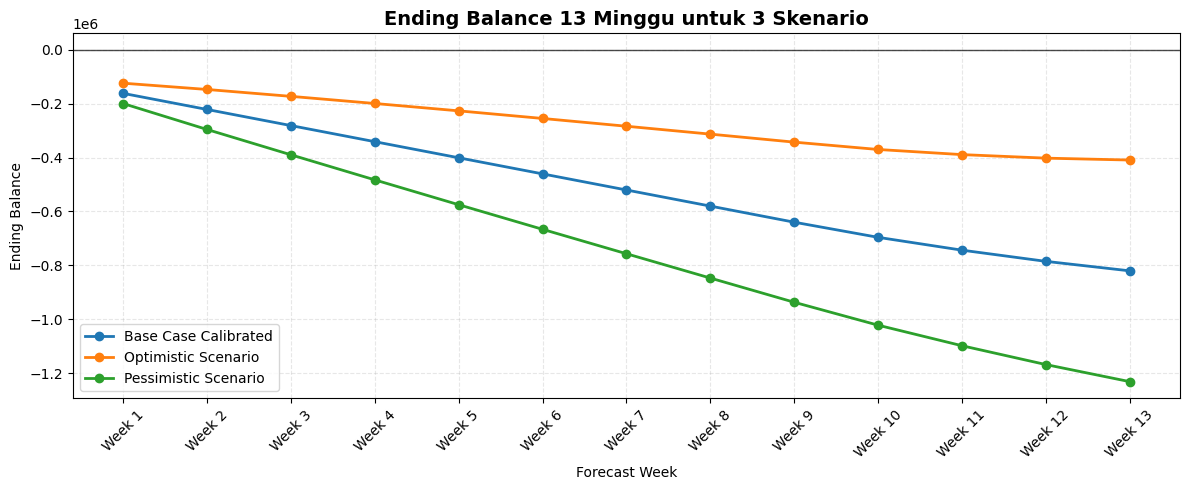

Grafik disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\netflow_scenarios.png


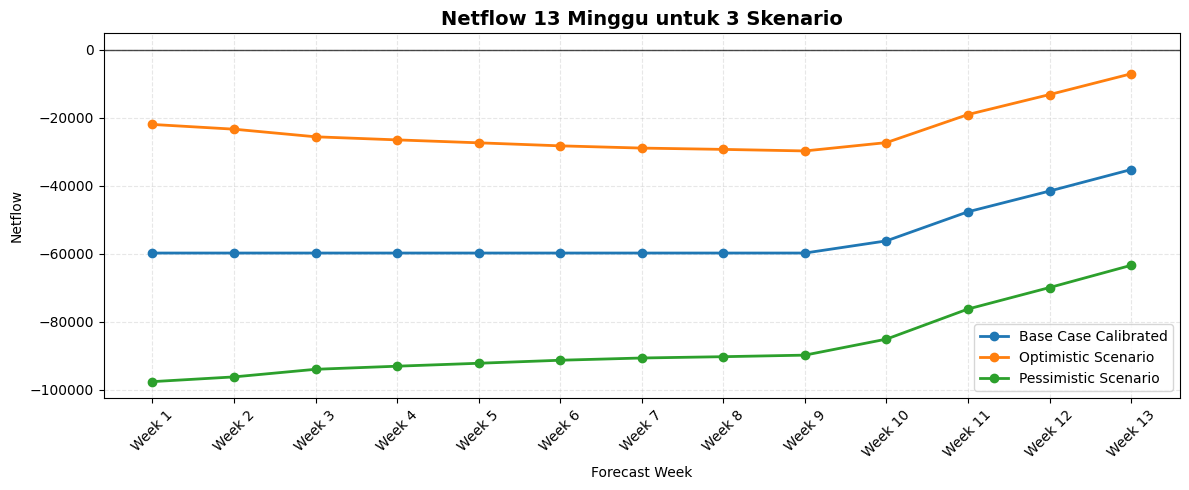

Grafik disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\inflow_outflow_scenarios.png


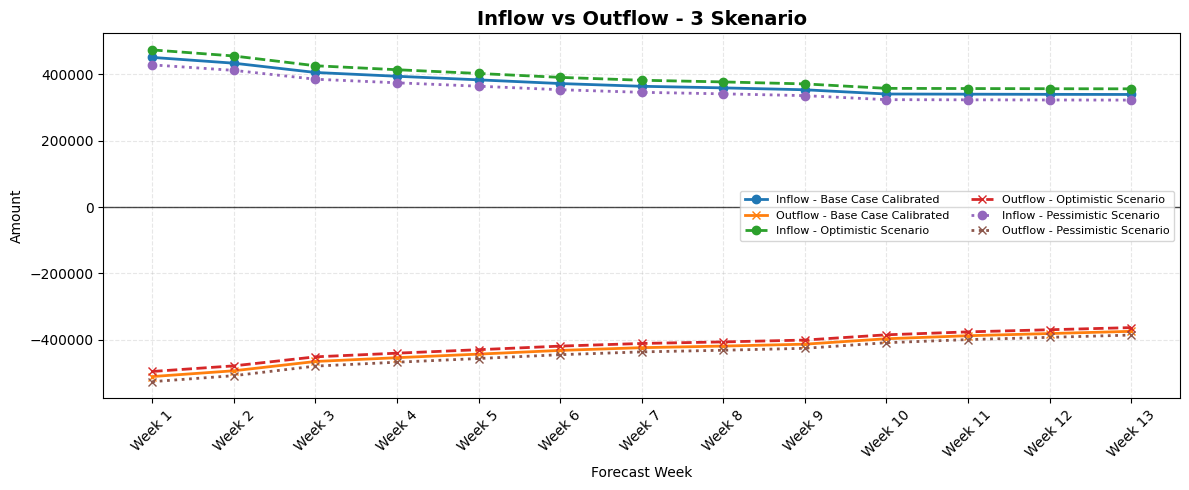

Grafik disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\cashflow_status.png


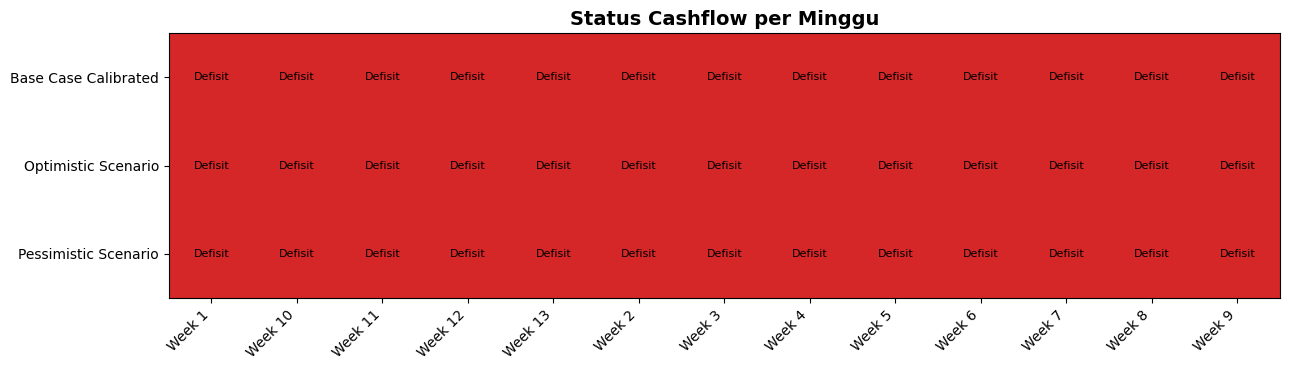

In [17]:
def save_plot(filename):
    output_path = output_dir / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print("Grafik disimpan ke:", output_path)


plot_data = final_output.copy()
plot_data["forecast_week_number"] = plot_data["forecast_week"].str.extract(r"(\d+)").astype(int)

plt.figure(figsize=(12, 5))
for scenario_name, scenario_df in plot_data.groupby("scenario", sort=False):
    plt.plot(
        scenario_df["forecast_week"],
        scenario_df["ending_balance"],
        marker="o",
        linewidth=2,
        label=scenario_name,
    )
plt.axhline(0, color="black", linewidth=1, alpha=0.7)
plt.title("Ending Balance 13 Minggu untuk 3 Skenario", fontsize=14, fontweight="bold")
plt.xlabel("Forecast Week")
plt.ylabel("Ending Balance")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_plot("ending_balance_scenarios.png")
plt.show()


plt.figure(figsize=(12, 5))
for scenario_name, scenario_df in plot_data.groupby("scenario", sort=False):
    plt.plot(
        scenario_df["forecast_week"],
        scenario_df["forecast_netflow"],
        marker="o",
        linewidth=2,
        label=scenario_name,
    )
plt.axhline(0, color="black", linewidth=1, alpha=0.7)
plt.title("Netflow 13 Minggu untuk 3 Skenario", fontsize=14, fontweight="bold")
plt.xlabel("Forecast Week")
plt.ylabel("Netflow")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_plot("netflow_scenarios.png")
plt.show()


plt.figure(figsize=(12, 5))
scenario_line_styles = {
    "Base Case Calibrated": "-",
    "Optimistic Scenario": "--",
    "Pessimistic Scenario": ":",
}
for scenario_name, scenario_df in plot_data.groupby("scenario", sort=False):
    plt.plot(
        scenario_df["forecast_week"],
        scenario_df["forecast_total_inflow"],
        marker="o",
        linewidth=2,
        linestyle=scenario_line_styles.get(scenario_name, "-"),
        label=f"Inflow - {scenario_name}",
    )
    plt.plot(
        scenario_df["forecast_week"],
        scenario_df["forecast_total_outflow"],
        marker="x",
        linewidth=2,
        linestyle=scenario_line_styles.get(scenario_name, "-"),
        label=f"Outflow - {scenario_name}",
    )
plt.axhline(0, color="black", linewidth=1, alpha=0.7)
plt.title("Inflow vs Outflow - 3 Skenario", fontsize=14, fontweight="bold")
plt.xlabel("Forecast Week")
plt.ylabel("Amount")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
save_plot("inflow_outflow_scenarios.png")
plt.show()


status_pivot = plot_data.pivot(index="scenario", columns="forecast_week", values="status")
status_to_value = {"Defisit": 0, "Waspada": 1, "Aman": 2}
status_values = status_pivot.replace(status_to_value).astype(float)
status_colors = ["#d62728", "#ffbf00", "#2ca02c"]

fig, ax = plt.subplots(figsize=(13, 3.8))
cmap = plt.matplotlib.colors.ListedColormap(status_colors)
im = ax.imshow(status_values.values, aspect="auto", cmap=cmap, vmin=0, vmax=2)

ax.set_xticks(np.arange(status_values.shape[1]))
ax.set_xticklabels(status_values.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(status_values.shape[0]))
ax.set_yticklabels(status_values.index)
ax.set_title("Status Cashflow per Minggu", fontsize=14, fontweight="bold")

for i in range(status_pivot.shape[0]):
    for j in range(status_pivot.shape[1]):
        ax.text(j, i, status_pivot.iloc[i, j], ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
save_plot("cashflow_status.png")
plt.show()

## 15. Export Output

Output yang diexport:

- `outputs/cashflow_forecast_13_weeks_scenarios.csv`
- `outputs/cashflow_forecast_13_weeks_scenarios.xlsx`
- `outputs/model_evaluation_metrics.csv`
- `outputs/model_evaluation_metrics.xlsx`

In [18]:
def write_simple_xlsx(df, output_path, sheet_name="sheet1"):
    import zipfile
    from html import escape

    def excel_column_name(index):
        index += 1
        name = ""
        while index:
            index, remainder = divmod(index - 1, 26)
            name = chr(65 + remainder) + name
        return name

    def cell_xml(row_index, col_index, value):
        cell_ref = f"{excel_column_name(col_index)}{row_index}"
        if pd.isna(value):
            return f'<c r="{cell_ref}" t="inlineStr"><is><t></t></is></c>'
        if isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool):
            return f'<c r="{cell_ref}"><v>{float(value)}</v></c>'
        text = escape(str(value))
        return f'<c r="{cell_ref}" t="inlineStr"><is><t>{text}</t></is></c>'

    rows_xml = []
    all_rows = [list(df.columns)] + df.astype(object).values.tolist()
    for row_index, row_values in enumerate(all_rows, start=1):
        cells_xml = "".join(cell_xml(row_index, col_index, value) for col_index, value in enumerate(row_values))
        rows_xml.append(f'<row r="{row_index}">{cells_xml}</row>')

    sheet_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<worksheet xmlns="http://schemas.openxmlformats.org/spreadsheetml/2006/main"><sheetData>'
        + "".join(rows_xml)
        + "</sheetData></worksheet>"
    )
    workbook_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<workbook xmlns="http://schemas.openxmlformats.org/spreadsheetml/2006/main" '
        'xmlns:r="http://schemas.openxmlformats.org/officeDocument/2006/relationships">'
        f'<sheets><sheet name="{escape(sheet_name)}" sheetId="1" r:id="rId1"/></sheets></workbook>'
    )
    workbook_rels_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Relationships xmlns="http://schemas.openxmlformats.org/package/2006/relationships">'
        '<Relationship Id="rId1" Type="http://schemas.openxmlformats.org/officeDocument/2006/relationships/worksheet" '
        'Target="worksheets/sheet1.xml"/></Relationships>'
    )
    root_rels_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Relationships xmlns="http://schemas.openxmlformats.org/package/2006/relationships">'
        '<Relationship Id="rId1" Type="http://schemas.openxmlformats.org/officeDocument/2006/relationships/officeDocument" '
        'Target="xl/workbook.xml"/></Relationships>'
    )
    content_types_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Types xmlns="http://schemas.openxmlformats.org/package/2006/content-types">'
        '<Default Extension="rels" ContentType="application/vnd.openxmlformats-package.relationships+xml"/>'
        '<Default Extension="xml" ContentType="application/xml"/>'
        '<Override PartName="/xl/workbook.xml" '
        'ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet.main+xml"/>'
        '<Override PartName="/xl/worksheets/sheet1.xml" '
        'ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.worksheet+xml"/></Types>'
    )

    with zipfile.ZipFile(output_path, "w", compression=zipfile.ZIP_DEFLATED) as workbook:
        workbook.writestr("[Content_Types].xml", content_types_xml)
        workbook.writestr("_rels/.rels", root_rels_xml)
        workbook.writestr("xl/workbook.xml", workbook_xml)
        workbook.writestr("xl/_rels/workbook.xml.rels", workbook_rels_xml)
        workbook.writestr("xl/worksheets/sheet1.xml", sheet_xml)


def export_csv_and_xlsx(df, csv_path, xlsx_path, sheet_name):
    df.to_csv(csv_path, index=False)
    print("CSV berhasil disimpan ke:", csv_path)

    try:
        df.to_excel(xlsx_path, index=False)
        print("Excel berhasil disimpan ke:", xlsx_path)
    except Exception as exc:
        print("Pandas to_excel gagal, menggunakan fallback .xlsx standard library.")
        print("Detail error:", exc)
        write_simple_xlsx(df, xlsx_path, sheet_name=sheet_name)
        print("Excel fallback berhasil disimpan ke:", xlsx_path)


forecast_csv_path = output_dir / "cashflow_forecast_13_weeks_scenarios.csv"
forecast_xlsx_path = output_dir / "cashflow_forecast_13_weeks_scenarios.xlsx"
metrics_csv_path = output_dir / "model_evaluation_metrics.csv"
metrics_xlsx_path = output_dir / "model_evaluation_metrics.xlsx"

export_csv_and_xlsx(final_output, forecast_csv_path, forecast_xlsx_path, "forecast_scenarios")
export_csv_and_xlsx(model_evaluation_metrics, metrics_csv_path, metrics_xlsx_path, "model_metrics")

CSV berhasil disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\cashflow_forecast_13_weeks_scenarios.csv
Pandas to_excel gagal, menggunakan fallback .xlsx standard library.
Detail error: No module named 'openpyxl'
Excel fallback berhasil disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\cashflow_forecast_13_weeks_scenarios.xlsx
CSV berhasil disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\model_evaluation_metrics.csv
Pandas to_excel gagal, menggunakan fallback .xlsx standard library.
Detail error: No module named 'openpyxl'
Excel fallback berhasil disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\model_evaluation_metrics.xlsx


## 16. Business Summary

Summary otomatis dibuat untuk membantu membaca hasil forecast:

- Ending balance terakhir data internal.
- Ending balance Week 13 untuk tiap skenario.
- Status Week 13 untuk tiap skenario.
- Minggu saat status berubah dari Defisit ke Waspada/Aman jika ada.
- Rekomendasi tindakan utama.

In [19]:
def find_first_recovery_week(scenario_df):
    scenario_df = scenario_df.copy().reset_index(drop=True)
    if scenario_df.empty:
        return "Tidak tersedia"

    first_status = scenario_df.loc[0, "status"]
    if first_status != "Defisit":
        return "Tidak mulai dari Defisit"

    recovery = scenario_df[scenario_df["status"].isin(["Waspada", "Aman"])]
    if recovery.empty:
        return "Belum recovery sampai Week 13"

    return recovery.iloc[0]["forecast_week"]


ending_balance_last_internal = internal_weekly["ending_balance"].iloc[-1]
summary_rows = []

for scenario_name, scenario_df in final_output.groupby("scenario", sort=False):
    scenario_df = scenario_df.reset_index(drop=True)
    week_13 = scenario_df[scenario_df["forecast_week"] == "Week 13"].iloc[0]
    summary_rows.append(
        {
            "scenario": scenario_name,
            "last_internal_ending_balance": ending_balance_last_internal,
            "week_13_ending_balance": week_13["ending_balance"],
            "week_13_status": week_13["status"],
            "first_recovery_week_from_deficit": find_first_recovery_week(scenario_df),
            "main_recommendation": week_13["recommended_action"],
        }
    )

business_summary = pd.DataFrame(summary_rows)
display(business_summary)

print("Rekomendasi tindakan utama:")
print("- Percepat collection AR, terutama pada minggu awal jika saldo masih defisit.")
print("- Tahan atau jadwalkan ulang pembayaran non-prioritas.")
print("- Negosiasi termin pembayaran vendor untuk menjaga buffer kas.")
print("- Jika defisit tetap berlanjut, pertimbangkan fasilitas revolving atau working capital.")

,scenario,last_internal_ending_balance,week_13_ending_balance,week_13_status,first_recovery_week_from_deficit,main_recommendation
0,Base Case Calibrated,"-101,616.00","-820,468.47",Defisit,Belum recovery sampai Week 13,Percepat collection AR dan penerimaan konsumen...
1,Optimistic Scenario,"-101,616.00","-408,966.11",Defisit,Belum recovery sampai Week 13,Percepat collection AR dan penerimaan konsumen...
2,Pessimistic Scenario,"-101,616.00","-1,231,970.82",Defisit,Belum recovery sampai Week 13,Percepat collection AR dan penerimaan konsumen...


Rekomendasi tindakan utama:
- Percepat collection AR, terutama pada minggu awal jika saldo masih defisit.
- Tahan atau jadwalkan ulang pembayaran non-prioritas.
- Negosiasi termin pembayaran vendor untuk menjaga buffer kas.
- Jika defisit tetap berlanjut, pertimbangkan fasilitas revolving atau working capital.


## 17. Conclusion

Data external digunakan untuk training karena data internal hanya 8 minggu. Model dievaluasi menggunakan MAE, RMSE, MAPE, dan R2 karena masalah ini adalah regression forecasting, bukan classification sehingga tidak menggunakan accuracy.

Direct model tidak digunakan sebagai hasil utama karena data external belum tentu sama dengan karakteristik bisnis perusahaan. Oleh karena itu, forecast dikalibrasi menggunakan tren netflow internal 4 minggu terakhir. Hasil akhir menggunakan **Base Case Calibrated** dan dilengkapi **Optimistic Scenario** serta **Pessimistic Scenario** untuk membaca risiko cashflow.

Forecast 13 minggu ini dapat digunakan untuk melihat risiko defisit dan menentukan tindakan seperti mempercepat collection, mengendalikan pembayaran non-prioritas, negosiasi vendor, atau menggunakan fasilitas working capital.

## 18. Scenario-Specific Output Tables

Bagian ini menampilkan output per skenario agar mudah dipresentasikan. Setiap cell berisi dua tabel: data aktual internal 8 minggu dan forecast 13 minggu untuk satu skenario. Kolom `scenario` dan `scenario_explanation` tidak ditampilkan di tabel; informasi skenario, asumsi, dan satuan ditaruh di judul/penjelasan agar tabel lebih rapi.

In [20]:
DISPLAY_NUMERIC_COLUMNS = [
    "total_inflow",
    "total_outflow",
    "netflow",
    "beginning_balance",
    "ending_balance",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
]


def format_number_with_comma(value):
    if pd.isna(value):
        return ""
    try:
        numeric_value = float(value)
    except Exception:
        return value
    return f"{numeric_value:,.0f}"


def format_table_for_presentation(df):
    formatted = df.copy()
    for column in DISPLAY_NUMERIC_COLUMNS:
        if column in formatted.columns:
            formatted[column] = formatted[column].apply(format_number_with_comma)
    return formatted

print("BASE CASE CALIBRATED - Satuan: Rp Juta")
print("Penjelasan:")
print("Base Case Calibrated adalah forecast utama. Angka ini berasal dari direct model forecast yang belajar pola cash in dan cash out dari data external, lalu dikalibrasi dengan rata-rata netflow 4 minggu terakhir data internal.")
print("Kalibrasi memakai bobot MODEL_WEIGHT = 0.4 dan INTERNAL_WEIGHT = 0.6, serta guardrail level inflow/outflow agar hasil tidak terlalu jauh dari skala aktual internal.")

FORECAST_PRESENTATION_COLUMNS = [
    "forecast_week",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
    "beginning_balance",
    "ending_balance",
    "status",
    "recommended_action",
    "action_detail",
]

internal_8_weeks_table = format_table_for_presentation(internal_weekly.copy())
base_case_table = format_table_for_presentation(
    final_output[final_output["scenario"] == "Base Case Calibrated"][FORECAST_PRESENTATION_COLUMNS].copy()
)

print("\nData Aktual Internal - 8 Minggu | Satuan: Rp Juta")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 1600):
    display(internal_8_weeks_table)

print("Forecast 13 Minggu - Base Case Calibrated | Satuan: Rp Juta")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 1600):
    display(base_case_table)

BASE CASE CALIBRATED - Satuan: Rp Juta
Penjelasan:
Base Case Calibrated adalah forecast utama. Angka ini berasal dari direct model forecast yang belajar pola cash in dan cash out dari data external, lalu dikalibrasi dengan rata-rata netflow 4 minggu terakhir data internal.
Kalibrasi memakai bobot MODEL_WEIGHT = 0.4 dan INTERNAL_WEIGHT = 0.6, serta guardrail level inflow/outflow agar hasil tidak terlalu jauh dari skala aktual internal.

Data Aktual Internal - 8 Minggu | Satuan: Rp Juta


,period,total_inflow,total_outflow,netflow,beginning_balance,ending_balance,week_number
0,May-26 W1,"799,295","-1,107,832","-308,537","337,737","29,200",1
1,May-26 W2,"173,661","-176,125","-2,464","29,200","26,736",2
2,May-26 W3,"376,621","-399,712","-23,091","26,736","3,645",3
3,May-26 W4,"708,743","-733,219","-24,476","3,646","-20,830",4
4,Jun-26 W1,"566,258","-549,650","16,608","-20,830","-4,222",5
5,Jun-26 W2,"818,142","-833,040","-14,898","-4,223","-19,121",6
6,Jun-26 W3,"388,910","-446,274","-57,364","-19,121","-76,485",7
7,Jun-26 W4,"483,221","-508,352","-25,131","-76,485","-101,616",8


Forecast 13 Minggu - Base Case Calibrated | Satuan: Rp Juta


,forecast_week,forecast_total_inflow,forecast_total_outflow,forecast_netflow,beginning_balance,ending_balance,status,recommended_action,action_detail
0,Week 1,"450,814","-510,614","-59,800","-101,616","-161,416",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
1,Week 2,"433,382","-493,182","-59,800","-161,416","-221,217",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
2,Week 3,"405,380","-465,180","-59,800","-221,217","-281,017",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
3,Week 4,"393,996","-453,796","-59,800","-281,017","-340,817",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
4,Week 5,"383,210","-443,010","-59,800","-340,817","-400,618",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
5,Week 6,"372,069","-431,869","-59,800","-400,618","-460,418",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
6,Week 7,"363,817","-423,618","-59,800","-460,418","-520,218",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
7,Week 8,"359,003","-418,803","-59,800","-520,218","-580,019",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
8,Week 9,"353,313","-413,113","-59,800","-580,019","-639,819",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
9,Week 10,"340,539","-396,755","-56,215","-639,819","-696,035",Defisit,Percepat collection AR dan penerimaan konsumen...,Week akhir: pertahankan cash discipline dan su...


In [21]:
DISPLAY_NUMERIC_COLUMNS = [
    "total_inflow",
    "total_outflow",
    "netflow",
    "beginning_balance",
    "ending_balance",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
]


def format_number_with_comma(value):
    if pd.isna(value):
        return ""
    try:
        numeric_value = float(value)
    except Exception:
        return value
    return f"{numeric_value:,.0f}"


def format_table_for_presentation(df):
    formatted = df.copy()
    for column in DISPLAY_NUMERIC_COLUMNS:
        if column in formatted.columns:
            formatted[column] = formatted[column].apply(format_number_with_comma)
    return formatted

print("OPTIMISTIC SCENARIO - Satuan: Rp Juta")
print("Penjelasan:")
print("Optimistic Scenario dibuat dari Base Case Calibrated, bukan dari direct model mentah. Skenario ini menggambarkan kondisi ketika collection sedikit membaik dan pengeluaran lebih terkendali.")
print("Rumus skenario: forecast_total_inflow dikali 1.05 atau naik 5%, sedangkan forecast_total_outflow dikali 0.97. Karena outflow bernilai negatif, dikali 0.97 berarti beban cash out lebih kecil 3%.")

FORECAST_PRESENTATION_COLUMNS = [
    "forecast_week",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
    "beginning_balance",
    "ending_balance",
    "status",
    "recommended_action",
    "action_detail",
]

internal_8_weeks_table = format_table_for_presentation(internal_weekly.copy())
optimistic_table = format_table_for_presentation(
    final_output[final_output["scenario"] == "Optimistic Scenario"][FORECAST_PRESENTATION_COLUMNS].copy()
)

print("\nData Aktual Internal - 8 Minggu | Satuan: Rp Juta")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 1600):
    display(internal_8_weeks_table)

print("Forecast 13 Minggu - Optimistic Scenario | Satuan: Rp Juta")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 1600):
    display(optimistic_table)

OPTIMISTIC SCENARIO - Satuan: Rp Juta
Penjelasan:
Optimistic Scenario dibuat dari Base Case Calibrated, bukan dari direct model mentah. Skenario ini menggambarkan kondisi ketika collection sedikit membaik dan pengeluaran lebih terkendali.
Rumus skenario: forecast_total_inflow dikali 1.05 atau naik 5%, sedangkan forecast_total_outflow dikali 0.97. Karena outflow bernilai negatif, dikali 0.97 berarti beban cash out lebih kecil 3%.

Data Aktual Internal - 8 Minggu | Satuan: Rp Juta


,period,total_inflow,total_outflow,netflow,beginning_balance,ending_balance,week_number
0,May-26 W1,"799,295","-1,107,832","-308,537","337,737","29,200",1
1,May-26 W2,"173,661","-176,125","-2,464","29,200","26,736",2
2,May-26 W3,"376,621","-399,712","-23,091","26,736","3,645",3
3,May-26 W4,"708,743","-733,219","-24,476","3,646","-20,830",4
4,Jun-26 W1,"566,258","-549,650","16,608","-20,830","-4,222",5
5,Jun-26 W2,"818,142","-833,040","-14,898","-4,223","-19,121",6
6,Jun-26 W3,"388,910","-446,274","-57,364","-19,121","-76,485",7
7,Jun-26 W4,"483,221","-508,352","-25,131","-76,485","-101,616",8


Forecast 13 Minggu - Optimistic Scenario | Satuan: Rp Juta


,forecast_week,forecast_total_inflow,forecast_total_outflow,forecast_netflow,beginning_balance,ending_balance,status,recommended_action,action_detail
13,Week 1,"473,355","-495,296","-21,941","-101,616","-123,557",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
14,Week 2,"455,051","-478,387","-23,336","-123,557","-146,893",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
15,Week 3,"425,649","-451,225","-25,576","-146,893","-172,469",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
16,Week 4,"413,696","-440,182","-26,487","-172,469","-198,956",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
17,Week 5,"402,371","-429,720","-27,350","-198,956","-226,305",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
18,Week 6,"390,672","-418,913","-28,241","-226,305","-254,546",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
19,Week 7,"382,008","-410,909","-28,901","-254,546","-283,447",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
20,Week 8,"376,953","-406,239","-29,286","-283,447","-312,733",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
21,Week 9,"370,979","-400,720","-29,741","-312,733","-342,474",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
22,Week 10,"357,566","-384,852","-27,286","-342,474","-369,760",Defisit,Percepat collection AR dan penerimaan konsumen...,Week akhir: pertahankan cash discipline dan su...


In [22]:
DISPLAY_NUMERIC_COLUMNS = [
    "total_inflow",
    "total_outflow",
    "netflow",
    "beginning_balance",
    "ending_balance",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
]


def format_number_with_comma(value):
    if pd.isna(value):
        return ""
    try:
        numeric_value = float(value)
    except Exception:
        return value
    return f"{numeric_value:,.0f}"


def format_table_for_presentation(df):
    formatted = df.copy()
    for column in DISPLAY_NUMERIC_COLUMNS:
        if column in formatted.columns:
            formatted[column] = formatted[column].apply(format_number_with_comma)
    return formatted

print("PESSIMISTIC SCENARIO - Satuan: Rp Juta")
print("Penjelasan:")
print("Pessimistic Scenario dibuat dari Base Case Calibrated. Skenario ini menggambarkan kondisi ketika penerimaan sedikit terlambat atau turun, sementara pembayaran atau pengeluaran meningkat.")
print("Rumus skenario: forecast_total_inflow dikali 0.95 atau turun 5%, sedangkan forecast_total_outflow dikali 1.03. Karena outflow bernilai negatif, dikali 1.03 berarti cash out lebih besar 3% dan risiko defisit meningkat.")

FORECAST_PRESENTATION_COLUMNS = [
    "forecast_week",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
    "beginning_balance",
    "ending_balance",
    "status",
    "recommended_action",
    "action_detail",
]

internal_8_weeks_table = format_table_for_presentation(internal_weekly.copy())
pessimistic_table = format_table_for_presentation(
    final_output[final_output["scenario"] == "Pessimistic Scenario"][FORECAST_PRESENTATION_COLUMNS].copy()
)

print("\nData Aktual Internal - 8 Minggu | Satuan: Rp Juta")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 1600):
    display(internal_8_weeks_table)

print("Forecast 13 Minggu - Pessimistic Scenario | Satuan: Rp Juta")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 1600):
    display(pessimistic_table)

PESSIMISTIC SCENARIO - Satuan: Rp Juta
Penjelasan:
Pessimistic Scenario dibuat dari Base Case Calibrated. Skenario ini menggambarkan kondisi ketika penerimaan sedikit terlambat atau turun, sementara pembayaran atau pengeluaran meningkat.
Rumus skenario: forecast_total_inflow dikali 0.95 atau turun 5%, sedangkan forecast_total_outflow dikali 1.03. Karena outflow bernilai negatif, dikali 1.03 berarti cash out lebih besar 3% dan risiko defisit meningkat.

Data Aktual Internal - 8 Minggu | Satuan: Rp Juta


,period,total_inflow,total_outflow,netflow,beginning_balance,ending_balance,week_number
0,May-26 W1,"799,295","-1,107,832","-308,537","337,737","29,200",1
1,May-26 W2,"173,661","-176,125","-2,464","29,200","26,736",2
2,May-26 W3,"376,621","-399,712","-23,091","26,736","3,645",3
3,May-26 W4,"708,743","-733,219","-24,476","3,646","-20,830",4
4,Jun-26 W1,"566,258","-549,650","16,608","-20,830","-4,222",5
5,Jun-26 W2,"818,142","-833,040","-14,898","-4,223","-19,121",6
6,Jun-26 W3,"388,910","-446,274","-57,364","-19,121","-76,485",7
7,Jun-26 W4,"483,221","-508,352","-25,131","-76,485","-101,616",8


Forecast 13 Minggu - Pessimistic Scenario | Satuan: Rp Juta


,forecast_week,forecast_total_inflow,forecast_total_outflow,forecast_netflow,beginning_balance,ending_balance,status,recommended_action,action_detail
26,Week 1,"428,273","-525,933","-97,659","-101,616","-199,275",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
27,Week 2,"411,713","-507,978","-96,265","-199,275","-295,540",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
28,Week 3,"385,111","-479,136","-94,025","-295,540","-389,565",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
29,Week 4,"374,296","-467,410","-93,114","-389,565","-482,679",Defisit,Percepat collection AR dan penerimaan konsumen...,"Week awal: fokus collection AR, tahan pembayar..."
30,Week 5,"364,050","-456,301","-92,251","-482,679","-574,930",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
31,Week 6,"353,465","-444,825","-91,360","-574,930","-666,290",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
32,Week 7,"345,626","-436,326","-90,700","-666,290","-756,990",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
33,Week 8,"341,052","-431,367","-90,315","-756,990","-847,305",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
34,Week 9,"335,647","-425,507","-89,859","-847,305","-937,164",Defisit,Percepat collection AR dan penerimaan konsumen...,Week tengah: kontrol outflow dan validasi jadw...
35,Week 10,"323,512","-408,657","-85,145","-937,164","-1,022,309",Defisit,Percepat collection AR dan penerimaan konsumen...,Week akhir: pertahankan cash discipline dan su...


## 19. Export XLSX Comparison Tables

Cell ini membuat file Excel khusus untuk presentasi. Isi file disusun dalam satu sheet: data aktual internal 8 minggu, lalu forecast Week 1-13 untuk Base Case Calibrated, Optimistic Scenario, dan Pessimistic Scenario. Kolom skenario tidak dimasukkan ke isi tabel karena sudah dijelaskan pada judul setiap blok. Semua nilai nominal menggunakan satuan Rp Juta.

In [23]:
DISPLAY_NUMERIC_COLUMNS = [
    "total_inflow",
    "total_outflow",
    "netflow",
    "beginning_balance",
    "ending_balance",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
]


def format_number_with_comma(value):
    if pd.isna(value):
        return ""
    try:
        numeric_value = float(value)
    except Exception:
        return value
    return f"{numeric_value:,.0f}"


def format_table_for_presentation(df):
    formatted = df.copy()
    for column in DISPLAY_NUMERIC_COLUMNS:
        if column in formatted.columns:
            formatted[column] = formatted[column].apply(format_number_with_comma)
    return formatted

comparison_xlsx_path = output_dir / "cashflow_forecast_13_weeks_comparison_tables.xlsx"

FORECAST_PRESENTATION_COLUMNS = [
    "forecast_week",
    "forecast_total_inflow",
    "forecast_total_outflow",
    "forecast_netflow",
    "beginning_balance",
    "ending_balance",
    "status",
    "recommended_action",
    "action_detail",
]

internal_8_weeks_table = format_table_for_presentation(internal_weekly.copy())
base_case_table = format_table_for_presentation(final_output[final_output["scenario"] == "Base Case Calibrated"][FORECAST_PRESENTATION_COLUMNS].copy())
optimistic_table = format_table_for_presentation(final_output[final_output["scenario"] == "Optimistic Scenario"][FORECAST_PRESENTATION_COLUMNS].copy())
pessimistic_table = format_table_for_presentation(final_output[final_output["scenario"] == "Pessimistic Scenario"][FORECAST_PRESENTATION_COLUMNS].copy())


def write_stacked_tables_xlsx(tables, output_path, sheet_name="comparison"):
    import zipfile
    from html import escape

    def excel_column_name(index):
        index += 1
        name = ""
        while index:
            index, remainder = divmod(index - 1, 26)
            name = chr(65 + remainder) + name
        return name

    def cell_xml(row_index, col_index, value, style_id=None):
        cell_ref = f"{excel_column_name(col_index)}{row_index}"
        style_attr = f' s="{style_id}"' if style_id is not None else ""
        text = "" if pd.isna(value) else escape(str(value))
        return f'<c r="{cell_ref}"{style_attr} t="inlineStr"><is><t>{text}</t></is></c>'

    rows_xml = []
    row_index = 1

    for title, df in tables:
        rows_xml.append(f'<row r="{row_index}">{cell_xml(row_index, 0, title, style_id=1)}</row>')
        row_index += 1

        header_cells = "".join(cell_xml(row_index, col_index, column, style_id=1) for col_index, column in enumerate(df.columns))
        rows_xml.append(f'<row r="{row_index}">{header_cells}</row>')
        row_index += 1

        for row_values in df.astype(object).values.tolist():
            cells_xml = "".join(cell_xml(row_index, col_index, value) for col_index, value in enumerate(row_values))
            rows_xml.append(f'<row r="{row_index}">{cells_xml}</row>')
            row_index += 1

        row_index += 2

    max_columns = max(len(df.columns) for _, df in tables)
    column_xml = "".join(f'<col min="{idx}" max="{idx}" width="24" customWidth="1"/>' for idx in range(1, max_columns + 1))

    sheet_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<worksheet xmlns="http://schemas.openxmlformats.org/spreadsheetml/2006/main">'
        f'<cols>{column_xml}</cols>'
        '<sheetData>'
        + "".join(rows_xml)
        + '</sheetData></worksheet>'
    )

    styles_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<styleSheet xmlns="http://schemas.openxmlformats.org/spreadsheetml/2006/main">'
        '<fonts count="2"><font><sz val="11"/><name val="Calibri"/></font><font><b/><sz val="11"/><name val="Calibri"/></font></fonts>'
        '<fills count="1"><fill><patternFill patternType="none"/></fill></fills>'
        '<borders count="1"><border><left/><right/><top/><bottom/><diagonal/></border></borders>'
        '<cellStyleXfs count="1"><xf numFmtId="0" fontId="0" fillId="0" borderId="0"/></cellStyleXfs>'
        '<cellXfs count="2"><xf numFmtId="0" fontId="0" fillId="0" borderId="0" xfId="0"/>'
        '<xf numFmtId="0" fontId="1" fillId="0" borderId="0" xfId="0" applyFont="1"/></cellXfs>'
        '</styleSheet>'
    )

    workbook_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<workbook xmlns="http://schemas.openxmlformats.org/spreadsheetml/2006/main" '
        'xmlns:r="http://schemas.openxmlformats.org/officeDocument/2006/relationships">'
        f'<sheets><sheet name="{escape(sheet_name)}" sheetId="1" r:id="rId1"/></sheets></workbook>'
    )

    workbook_rels_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Relationships xmlns="http://schemas.openxmlformats.org/package/2006/relationships">'
        '<Relationship Id="rId1" Type="http://schemas.openxmlformats.org/officeDocument/2006/relationships/worksheet" Target="worksheets/sheet1.xml"/>'
        '<Relationship Id="rId2" Type="http://schemas.openxmlformats.org/officeDocument/2006/relationships/styles" Target="styles.xml"/>'
        '</Relationships>'
    )

    root_rels_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Relationships xmlns="http://schemas.openxmlformats.org/package/2006/relationships">'
        '<Relationship Id="rId1" Type="http://schemas.openxmlformats.org/officeDocument/2006/relationships/officeDocument" Target="xl/workbook.xml"/>'
        '</Relationships>'
    )

    content_types_xml = (
        '<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
        '<Types xmlns="http://schemas.openxmlformats.org/package/2006/content-types">'
        '<Default Extension="rels" ContentType="application/vnd.openxmlformats-package.relationships+xml"/>'
        '<Default Extension="xml" ContentType="application/xml"/>'
        '<Override PartName="/xl/workbook.xml" ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet.main+xml"/>'
        '<Override PartName="/xl/worksheets/sheet1.xml" ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.worksheet+xml"/>'
        '<Override PartName="/xl/styles.xml" ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.styles+xml"/>'
        '</Types>'
    )

    with zipfile.ZipFile(output_path, "w", compression=zipfile.ZIP_DEFLATED) as workbook:
        workbook.writestr("[Content_Types].xml", content_types_xml)
        workbook.writestr("_rels/.rels", root_rels_xml)
        workbook.writestr("xl/workbook.xml", workbook_xml)
        workbook.writestr("xl/_rels/workbook.xml.rels", workbook_rels_xml)
        workbook.writestr("xl/styles.xml", styles_xml)
        workbook.writestr("xl/worksheets/sheet1.xml", sheet_xml)


tables_for_comparison = [
    ("DATA AKTUAL INTERNAL - 8 MINGGU | Satuan: Rp Juta", internal_8_weeks_table),
    ("BASE CASE CALIBRATED | Satuan: Rp Juta | Asumsi: direct model dari data external dikalibrasi dengan tren netflow internal 4 minggu terakhir dan guardrail level inflow/outflow internal.", base_case_table),
    ("OPTIMISTIC SCENARIO | Satuan: Rp Juta | Asumsi: dari Base Case Calibrated, inflow naik 5% dan outflow turun 3% untuk menggambarkan collection membaik dan pengeluaran lebih terkendali.", optimistic_table),
    ("PESSIMISTIC SCENARIO | Satuan: Rp Juta | Asumsi: dari Base Case Calibrated, inflow turun 5% dan outflow naik 3% untuk menggambarkan penerimaan terlambat dan pembayaran meningkat.", pessimistic_table),
]

write_stacked_tables_xlsx(tables_for_comparison, comparison_xlsx_path, sheet_name="comparison")
print("Excel comparison berhasil disimpan ke:", comparison_xlsx_path)

Excel comparison berhasil disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\cashflow_forecast_13_weeks_comparison_tables.xlsx


## 20. Dashboard Visualization

Bagian ini membuat visualisasi ringkas bergaya dashboard agar hasil forecast mudah dipresentasikan. Dashboard menampilkan KPI saldo, tren ending balance 3 skenario, netflow, inflow vs outflow Base Case, dan status cashflow per minggu. Semua nominal menggunakan satuan Rp Juta.

Dashboard berhasil disimpan ke: C:\Users\Ram Wijaya\Documents\ram wijaya\KP MEI\cashflow-forecasting\outputs\cashflow_dashboard_summary.png


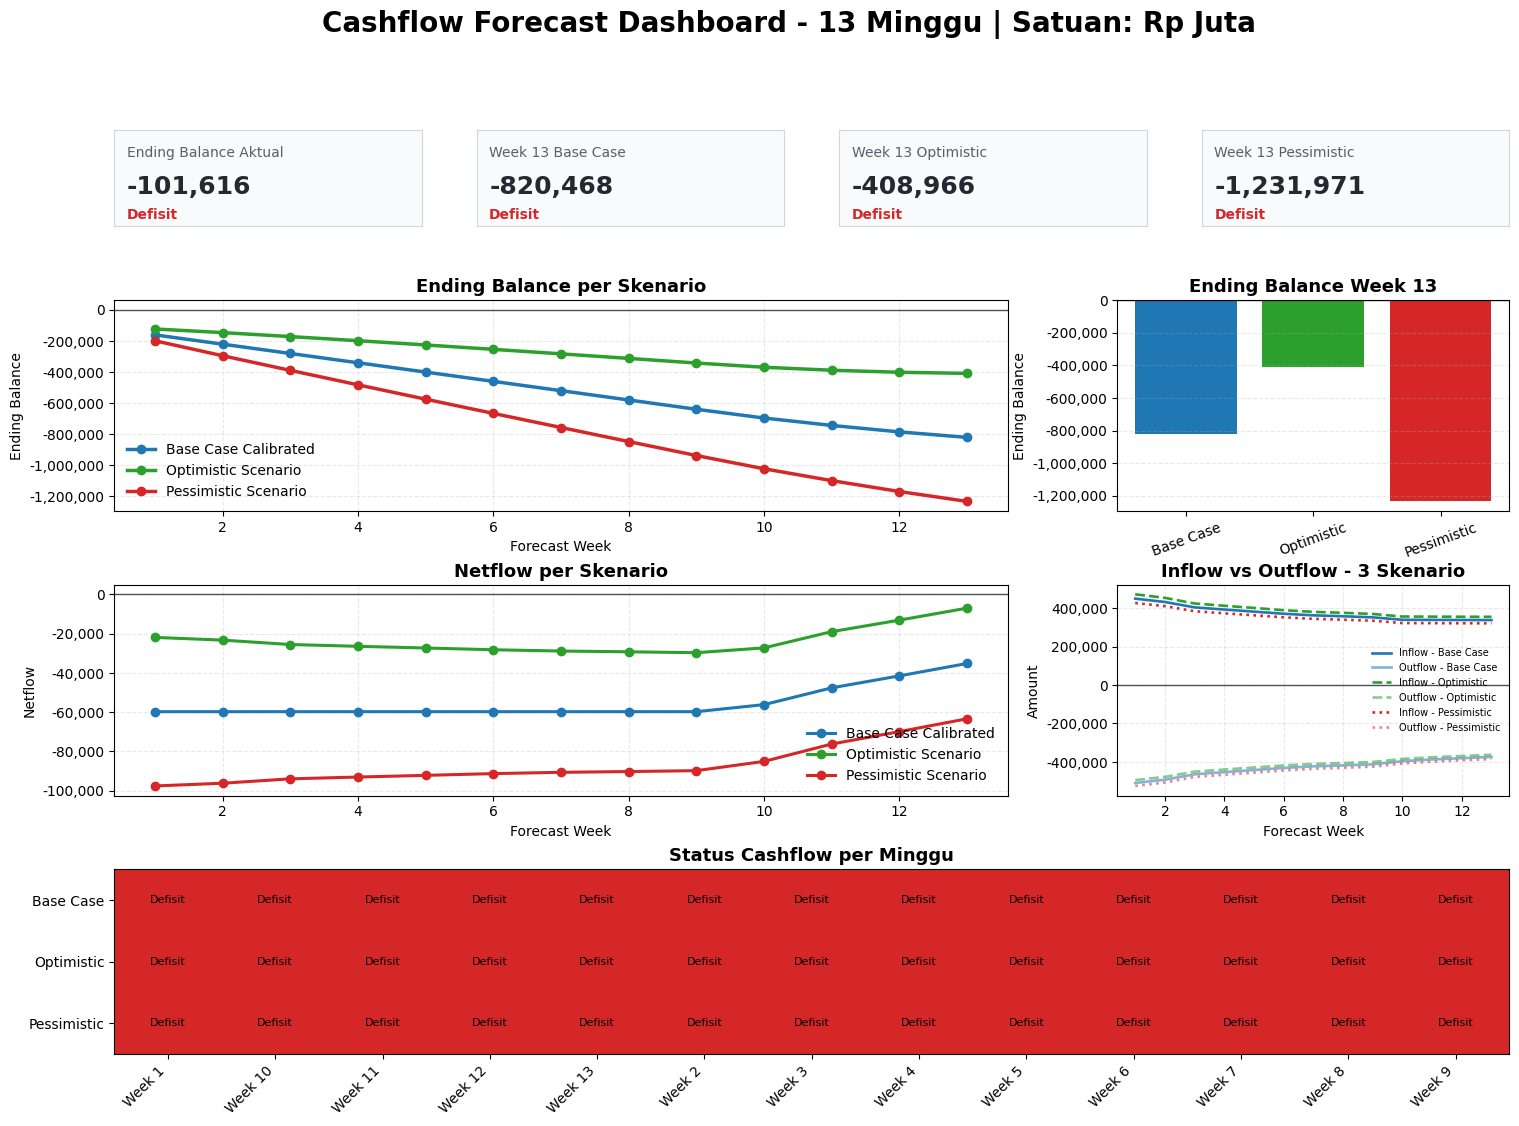

In [24]:
dashboard_output_path = output_dir / "cashflow_dashboard_summary.png"

dashboard_data = final_output.copy()
dashboard_data["forecast_week_number"] = dashboard_data["forecast_week"].str.extract(r"(\d+)").astype(int)

scenario_colors = {
    "Base Case Calibrated": "#1f77b4",
    "Optimistic Scenario": "#2ca02c",
    "Pessimistic Scenario": "#d62728",
}

status_colors = {
    "Aman": "#2ca02c",
    "Waspada": "#ffbf00",
    "Defisit": "#d62728",
}

last_internal_balance = internal_weekly["ending_balance"].iloc[-1]
week_13_summary = (
    dashboard_data[dashboard_data["forecast_week"] == "Week 13"]
    .set_index("scenario")[["ending_balance", "status"]]
    .loc[list(scenario_colors.keys())]
)


def format_rp_juta(value):
    return f"{value:,.0f}"


fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = fig.add_gridspec(
    nrows=4,
    ncols=3,
    height_ratios=[0.55, 1.2, 1.2, 1.05],
    hspace=0.42,
    wspace=0.28,
)

fig.suptitle(
    "Cashflow Forecast Dashboard - 13 Minggu | Satuan: Rp Juta",
    fontsize=20,
    fontweight="bold",
    y=0.98,
)

# KPI cards
kpi_titles = [
    "Ending Balance Aktual",
    "Week 13 Base Case",
    "Week 13 Optimistic",
    "Week 13 Pessimistic",
]
kpi_values = [
    format_rp_juta(last_internal_balance),
    format_rp_juta(week_13_summary.loc["Base Case Calibrated", "ending_balance"]),
    format_rp_juta(week_13_summary.loc["Optimistic Scenario", "ending_balance"]),
    format_rp_juta(week_13_summary.loc["Pessimistic Scenario", "ending_balance"]),
]
kpi_statuses = [
    assign_status(last_internal_balance),
    week_13_summary.loc["Base Case Calibrated", "status"],
    week_13_summary.loc["Optimistic Scenario", "status"],
    week_13_summary.loc["Pessimistic Scenario", "status"],
]

kpi_grid = gs[0, :].subgridspec(1, 4, wspace=0.18)
for idx, (title, value, status) in enumerate(zip(kpi_titles, kpi_values, kpi_statuses)):
    ax = fig.add_subplot(kpi_grid[0, idx])
    ax.set_facecolor("#f8fafc")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("#d0d7de")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.72, title, fontsize=10, color="#57606a", transform=ax.transAxes)
    ax.text(0.04, 0.34, value, fontsize=18, fontweight="bold", color="#24292f", transform=ax.transAxes)
    ax.text(
        0.04,
        0.08,
        status,
        fontsize=10,
        fontweight="bold",
        color=status_colors.get(status, "#24292f"),
        transform=ax.transAxes,
    )

# Ending balance by scenario
ax1 = fig.add_subplot(gs[1, :2])
for scenario_name, scenario_df in dashboard_data.groupby("scenario", sort=False):
    ax1.plot(
        scenario_df["forecast_week_number"],
        scenario_df["ending_balance"],
        marker="o",
        linewidth=2.5,
        label=scenario_name,
        color=scenario_colors.get(scenario_name),
    )
ax1.axhline(0, color="#24292f", linewidth=1, alpha=0.8)
ax1.set_title("Ending Balance per Skenario", fontsize=13, fontweight="bold")
ax1.set_xlabel("Forecast Week")
ax1.set_ylabel("Ending Balance")
ax1.grid(True, linestyle="--", alpha=0.28)
ax1.legend(frameon=False, loc="best")
ax1.yaxis.set_major_formatter(lambda value, pos: f"{value:,.0f}")

# Week 13 ending balance bar
ax2 = fig.add_subplot(gs[1, 2])
bar_labels = [label.replace(" Scenario", "").replace(" Calibrated", "") for label in week_13_summary.index]
bar_values = week_13_summary["ending_balance"].values
bar_colors = [scenario_colors[name] for name in week_13_summary.index]
ax2.bar(bar_labels, bar_values, color=bar_colors)
ax2.axhline(0, color="#24292f", linewidth=1, alpha=0.8)
ax2.set_title("Ending Balance Week 13", fontsize=13, fontweight="bold")
ax2.set_ylabel("Ending Balance")
ax2.tick_params(axis="x", rotation=20)
ax2.grid(True, axis="y", linestyle="--", alpha=0.28)
ax2.yaxis.set_major_formatter(lambda value, pos: f"{value:,.0f}")

# Netflow by scenario
ax3 = fig.add_subplot(gs[2, :2])
for scenario_name, scenario_df in dashboard_data.groupby("scenario", sort=False):
    ax3.plot(
        scenario_df["forecast_week_number"],
        scenario_df["forecast_netflow"],
        marker="o",
        linewidth=2.2,
        label=scenario_name,
        color=scenario_colors.get(scenario_name),
    )
ax3.axhline(0, color="#24292f", linewidth=1, alpha=0.8)
ax3.set_title("Netflow per Skenario", fontsize=13, fontweight="bold")
ax3.set_xlabel("Forecast Week")
ax3.set_ylabel("Netflow")
ax3.grid(True, linestyle="--", alpha=0.28)
ax3.legend(frameon=False, loc="best")
ax3.yaxis.set_major_formatter(lambda value, pos: f"{value:,.0f}")

# Inflow vs outflow by scenario
ax4 = fig.add_subplot(gs[2, 2])
scenario_line_styles = {
    "Base Case Calibrated": "-",
    "Optimistic Scenario": "--",
    "Pessimistic Scenario": ":",
}
for scenario_name, scenario_df in dashboard_data.groupby("scenario", sort=False):
    ax4.plot(
        scenario_df["forecast_week_number"],
        scenario_df["forecast_total_inflow"],
        linewidth=1.9,
        linestyle=scenario_line_styles.get(scenario_name, "-"),
        color=scenario_colors.get(scenario_name),
        label=f"Inflow - {scenario_name.replace(' Scenario', '').replace(' Calibrated', '')}",
    )
    ax4.plot(
        scenario_df["forecast_week_number"],
        scenario_df["forecast_total_outflow"],
        linewidth=1.9,
        linestyle=scenario_line_styles.get(scenario_name, "-"),
        color=scenario_colors.get(scenario_name),
        alpha=0.55,
        label=f"Outflow - {scenario_name.replace(' Scenario', '').replace(' Calibrated', '')}",
    )
ax4.axhline(0, color="#24292f", linewidth=1, alpha=0.8)
ax4.set_title("Inflow vs Outflow - 3 Skenario", fontsize=13, fontweight="bold")
ax4.set_xlabel("Forecast Week")
ax4.set_ylabel("Amount")
ax4.grid(True, linestyle="--", alpha=0.28)
ax4.legend(frameon=False, fontsize=7, ncol=1)
ax4.yaxis.set_major_formatter(lambda value, pos: f"{value:,.0f}")

# Status heatmap
ax5 = fig.add_subplot(gs[3, :])
status_pivot = dashboard_data.pivot(index="scenario", columns="forecast_week", values="status")
status_pivot = status_pivot.loc[list(scenario_colors.keys())]
status_to_value = {"Defisit": 0, "Waspada": 1, "Aman": 2}
status_values = status_pivot.replace(status_to_value).astype(float)
cmap = plt.matplotlib.colors.ListedColormap(["#d62728", "#ffbf00", "#2ca02c"])
ax5.imshow(status_values.values, aspect="auto", cmap=cmap, vmin=0, vmax=2)
ax5.set_title("Status Cashflow per Minggu", fontsize=13, fontweight="bold")
ax5.set_xticks(np.arange(status_values.shape[1]))
ax5.set_xticklabels(status_values.columns, rotation=45, ha="right")
ax5.set_yticks(np.arange(status_values.shape[0]))
ax5.set_yticklabels([label.replace(" Scenario", "").replace(" Calibrated", "") for label in status_values.index])

for i in range(status_pivot.shape[0]):
    for j in range(status_pivot.shape[1]):
        ax5.text(j, i, status_pivot.iloc[i, j], ha="center", va="center", color="black", fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(dashboard_output_path, dpi=180, bbox_inches="tight")
print("Dashboard berhasil disimpan ke:", dashboard_output_path)
plt.show()